In [ ]:
# LLM intent and enitity extraction

In [66]:
import os
import json
from groq import Groq
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import JsonOutputParser
from pydantic import BaseModel, Field
from typing import List

load_dotenv(r"E:\Rohanta_AI_workbook\campus_chatbot\.env")
client = Groq(api_key=os.getenv("GROQ_API_KEY"))

In [67]:
class IntentEntity(BaseModel):
    intent: str = Field(description="one of: find_location, opening_hours, events, description, navigation, general")
    entities: List[str] = Field(description="location or place names mentioned in the query")
    category_hints: List[str] = Field(description="must include relevant words from this list only: library, gym, cafeteria, lab, department, hod_office, auditorium, medical_center, career_center, student_union, admin_office, security_office, printing_room, classroom, seminar_room")

In [68]:
llm = ChatGroq(
    model="llama-3.1-8b-instant",
    temperature=0.0,
    max_tokens=200,
)

In [69]:
parser = JsonOutputParser(pydantic_object=IntentEntity)

In [81]:
prompt = PromptTemplate(
    template="""Extract intent and entities from the user query.
{format_instructions}

Valid intents:
- find_location : user wants to find or get directions to a place.
                  e.g. "Where is the library?", "How do I get to the gym?",
                  "Where can I eat?", "Where can I get coffee?",
                  "Where can I exercise?", "Where do students socialise?",
                  "I need to find a place to study", "Where can I get a hot drink?"
                  NOTE: ANY query about finding a place, food, drink, study area,
                  social area, or exercise area = find_location.
                  "Where can I get X?" = find_location always.
                  "I need to find X" = find_location always.
                  "Where do students X?" = find_location always.

- ask_hours     : user wants to know timings or if a place is open.
                  e.g. "What time does the library open?",
                  "Is the gym open on Sunday?", "When does the cafe close?",
                  "Is the office open on Saturday?"
                  NOTE: "Is X open on Y?" = ask_hours always.

- find_event    : user wants to know about events, workshops, competitions, activities.
                  e.g. "What events are at the library?",
                  "Are there any workshops?", "Are there sports events this week?",
                  "Is there a hackathon coming up?", "What career events are coming up?"
                  NOTE: Any query about workshops, competitions, fairs, events = find_event.

For entities — extract the OFFICIAL campus location name, not just the words in the query.
Use these mappings:
- "library", "books", "study desks", "place to study" → Main Library
- "cafeteria", "canteen", "food", "dining area", "eat", "hungry" → Main Cafeteria
- "coffee", "cafe", "hot drink", "coffee shop" → Campus Coffee Shop
- "student union", "SU", "socialise", "social area" → Student Union
- "gym", "fitness", "sports centre", "exercise", "run", "workout" → Sports & Fitness Centre
- "IT lab", "computer lab", "computer room", "PC" → IT & Computer Lab
- "print", "printing room", "photocopy" → Printing & Stationery Centre
- "admissions", "registry", "student ID", "registration" → Admissions & Registry Office
- "career", "CV", "job listings", "employability" → Career Services Centre
- "medical", "doctor", "health centre", "unwell" → Medical & Counselling Centre
- "auditorium", "main hall", "graduation" → Main Auditorium
- "security", "lost item", "campus security" → Campus Security Office
- "research lab", "innovation centre", "hackathon" → Research & Innovation Lab
- "garden", "outdoor", "outside", "benches" → Campus Garden & Outdoor Study Area
- "accommodation", "housing", "student housing" → Student Accommodation Office
- "engineering block", "engineering college" → Engineering College - Main Block

User query: {query}
""",
    input_variables=["query"],
    partial_variables={"format_instructions": parser.get_format_instructions()},
)


In [82]:
chain = prompt | llm | parser

In [113]:
import pandas as pd
import time
import matplotlib.pyplot as plt

df_faq = pd.read_csv(r"E:\Rohanta_AI_workbook\campus_chatbot\data\faq.csv")
print(f"Total rows     : {len(df_faq)}")
print(f"Unique intents : {df_faq['intent'].unique().tolist()}")
print(f"Unique entities: {df_faq['entity'].nunique()}")
print(f"\nIntent distribution:\n{df_faq['intent'].value_counts()}")

Total rows     : 734
Unique intents : ['find_location', 'ask_hours', 'find_event']
Unique entities: 151

Intent distribution:
intent
find_location    517
ask_hours        184
find_event        33
Name: count, dtype: int64


In [84]:
df_faq = df_faq.head(50)

In [85]:
INTENT_MAP = {
    "find_location": "find_location",
    "ask_hours":     "ask_hours",
    "find_event":    "find_event",
}

results = []
for i, row in df_faq.iterrows():
    try:
        result        = chain.invoke({"query": row["query"]})
        pred_intent   = result["intent"]
        pred_entities = result["entities"]
    except Exception as e:
        pred_intent   = "error"
        pred_entities = []
        print(f"Error on row {i+1}: {e}")

    expected_intent = INTENT_MAP.get(row["intent"], row["intent"])
    expected_entity = row["entity"]

    intent_correct = pred_intent == expected_intent

    entity_correct = any(
        expected_entity.lower() in e.lower() or e.lower() in expected_entity.lower()
        for e in pred_entities
    ) if pred_entities else False

    results.append({
        "query":              row["query"],
        "expected_intent":    expected_intent,
        "predicted_intent":   pred_intent,
        "intent_correct":     intent_correct,
        "expected_entity":    expected_entity,
        "predicted_entities": pred_entities,
        "entity_correct":     entity_correct,
    })

    time.sleep(0.5)
    if (i + 1) % 10 == 0:
        print(f"[{i+1}/{len(df_faq)}] done")

print("\nAll done!")

[10/50] done
[20/50] done
[30/50] done
[40/50] done
[50/50] done

All done!


In [86]:
df_results = pd.DataFrame(results)

total          = len(df_results)
intent_correct = df_results["intent_correct"].sum()
entity_correct = df_results["entity_correct"].sum()
both_correct   = (df_results["intent_correct"] & df_results["entity_correct"]).sum()

print(f"Total samples   : {total}")
print(f"Intent accuracy : {intent_correct}/{total} = {intent_correct/total*100:.1f}%")
print(f"Entity accuracy : {entity_correct}/{total} = {entity_correct/total*100:.1f}%")
print(f"Both correct    : {both_correct}/{total} = {both_correct/total*100:.1f}%")

Total samples   : 50
Intent accuracy : 49/50 = 98.0%
Entity accuracy : 49/50 = 98.0%
Both correct    : 48/50 = 96.0%


In [87]:
per_intent = df_results.groupby("expected_intent").agg(
    total          = ("intent_correct", "count"),
    intent_correct = ("intent_correct", "sum"),
    entity_correct = ("entity_correct", "sum"),
).reset_index()

per_intent["intent_acc"] = (per_intent["intent_correct"] / per_intent["total"] * 100).round(1)
per_intent["entity_acc"] = (per_intent["entity_correct"] / per_intent["total"] * 100).round(1)
per_intent

,expected_intent,total,intent_correct,entity_correct,intent_acc,entity_acc
0,ask_hours,18,17,17,94.4,94.4
1,find_event,8,8,8,100.0,100.0
2,find_location,24,24,24,100.0,100.0


In [88]:
print("=== Failed Intent Predictions ===\n")
failed_intent = df_results[df_results["intent_correct"] == False]
print(f"Total failed: {len(failed_intent)}\n")
for _, row in failed_intent.iterrows():
    print(f"Query    : {row['query']}")
    print(f"Expected : {row['expected_intent']}")
    print(f"Got      : {row['predicted_intent']}")
    print("-" * 50)

=== Failed Intent Predictions ===

Total failed: 1

Query    : What are the library opening hours?
Expected : ask_hours
Got      : opening_hours
--------------------------------------------------


In [89]:
print("=== Failed Entity Predictions ===\n")
failed_entity = df_results[df_results["entity_correct"] == False]
print(f"Total failed: {len(failed_entity)}\n")
for _, row in failed_entity.iterrows():
    print(f"Query     : {row['query']}")
    print(f"Expected  : {row['expected_entity']}")
    print(f"Got       : {row['predicted_entities']}")
    print("-" * 50)

=== Failed Entity Predictions ===

Total failed: 1

Query     : When does the cafe close?
Expected  : Campus Coffee Shop
Got       : ['Main Cafeteria']
--------------------------------------------------


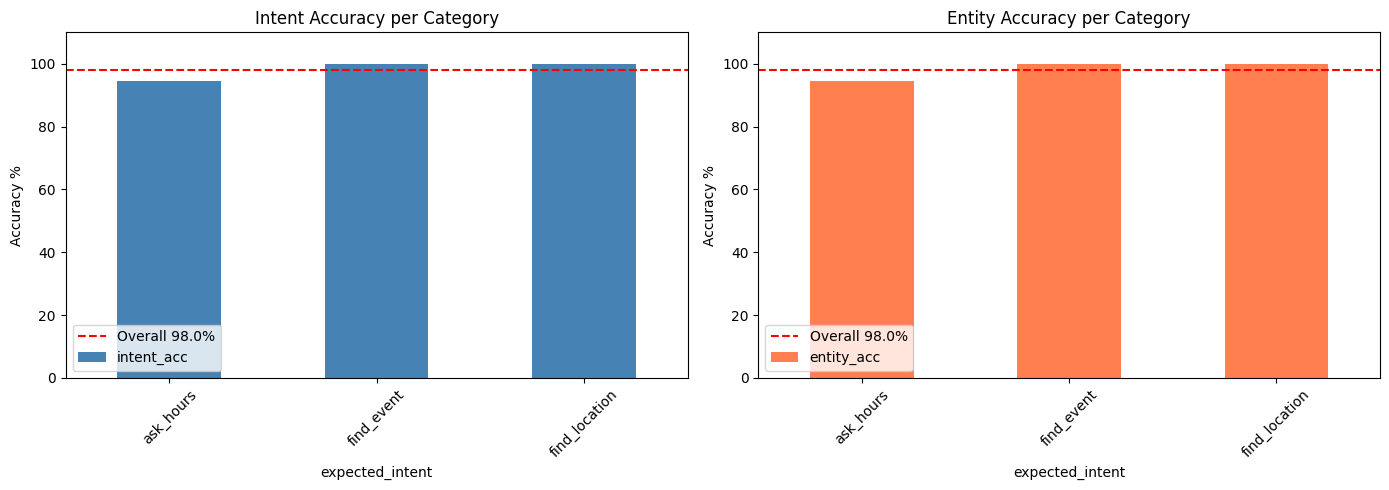

In [90]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

per_intent.plot(
    x="expected_intent", y="intent_acc",
    kind="bar", ax=axes[0],
    title="Intent Accuracy per Category",
    color="steelblue", legend=False
)
axes[0].set_ylabel("Accuracy %")
axes[0].set_ylim(0, 110)
axes[0].axhline(y=intent_correct/total*100, color="red", linestyle="--",
                label=f"Overall {intent_correct/total*100:.1f}%")
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

per_intent.plot(
    x="expected_intent", y="entity_acc",
    kind="bar", ax=axes[1],
    title="Entity Accuracy per Category",
    color="coral", legend=False
)
axes[1].set_ylabel("Accuracy %")
axes[1].set_ylim(0, 110)
axes[1].axhline(y=entity_correct/total*100, color="red", linestyle="--",
                label=f"Overall {entity_correct/total*100:.1f}%")
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [91]:
per_entity = df_results.groupby("expected_entity").agg(
    total          = ("intent_correct", "count"),
    intent_correct = ("intent_correct", "sum"),
    entity_correct = ("entity_correct", "sum"),
).reset_index()

per_entity["intent_acc"] = (per_entity["intent_correct"] / per_entity["total"] * 100).round(1)
per_entity["entity_acc"] = (per_entity["entity_correct"] / per_entity["total"] * 100).round(1)

print("=== Bottom 10 entities by entity accuracy ===")
per_entity.sort_values("entity_acc").head(10)

=== Bottom 10 entities by entity accuracy ===


,expected_entity,total,intent_correct,entity_correct,intent_acc,entity_acc
0,Campus Coffee Shop,7,7,6,100.0,85.7
1,Main Cafeteria,10,10,10,100.0,100.0
2,Main Library,12,11,12,91.7,100.0
3,Sports & Fitness Centre,11,11,11,100.0,100.0
4,Student Union,10,10,10,100.0,100.0


In [36]:
# fallback ofline intent and entity extraction

In [40]:
import re

In [163]:
INTENT_PATTERNS = {
    "find_location": [
        r"\bwhere\b", r"\blocation\b", r"\bdirections?\b",
        r"\bhow (do i|to) (get|reach|find|go)\b",
        r"\bfind\b", r"\bnavigate\b", r"\broom\b", r"\bfloor\b", r"\bbuilding\b",
    ],
    "opening_hours": [
        r"\bopen(ing)?\b", r"\bclos(e|ing|ed)\b", r"\bhours?\b",
        r"\btime\b", r"\bwhen\b", r"\bschedule\b", r"\btiming\b",
        r"\bopen on\b",
    ],
    "events": [
    r"\bevents?\b", r"\bworkshops?\b", r"\bseminars?\b",
    r"\bfestival\b", r"\bupcoming\b", r"\bhappening\b",
    r"\bcompetitions?\b", r"\bhackathon\b", r"\bfairs?\b",
    r"\bactivit(y|ies)\b", r"\bon at\b", r"\banything on\b",
    r"\bscheduled\b", r"\bexhibition\b", r"\bexpo\b",
    r"\bare there any\b",
    ],
    "description": [
        r"\bwhat is\b", r"\btell me about\b", r"\bdescribe\b",
        r"\bfacilities?\b", r"\bservices?\b", r"\bdetails?\b",
    ],
    "navigation": [
        r"\bfrom\b.+\bto\b", r"\bgo from\b", r"\broute from\b",
    ],
}


In [164]:
CATEGORY_KEYWORDS = {
    "library":        ["library", "books", "reading"],
    "cafeteria":      ["cafeteria", "canteen", "food", "eat", "meal"],
    "gym":            ["gym", "fitness", "sports", "yoga", "workout"],
    "it_lab":         ["it lab", "computer lab", "pc"],
    "department":     ["department", "dept"],
    "hod_office":     ["hod", "head of department"],
    "auditorium":     ["auditorium"],
    "medical_center": ["medical", "health", "clinic", "doctor"],
    "career_center":  ["career", "job", "placement"],
    "student_union":  ["student union", "union", "lounge"],
    "admin_office":   ["admission", "registry", "enrollment"],
    "lab":            ["lab", "laboratory"],
    "classroom":      ["classroom"],
    "seminar_room":   ["seminar room", "seminar"],
    "printing_room":  ["print", "photocopy"],
    "security_office":["security", "guard"],
}

In [187]:
ENTITY_MAP = {
    "library":         ["library", "books", "study desks", "place to study", "reading"],
    "cafeteria":       ["cafeteria", "canteen", "food", "eat", "meal", "dining area", "hungry"],
    "coffee shop":     ["coffee", "cafe", "hot drink", "coffee shop"],
    "student union":   ["student union", "su", "socialise", "social area", "student lounge"],
    "gym":             ["gym", "fitness", "sports centre", "exercise", "run", "workout", "sports"],
    "it lab":          ["it lab", "computer lab", "pc", "use a computer", "computer room"],
    "printing":        ["print", "printing room", "photocopy"],
    "admissions":      ["admissions", "registry", "student id", "registration", "enrollment", "dissertation"],
    "career":          ["career centre", "career services", "career advice", "cv help", 
                        "cv workshop", "job listings", "careers and employability", 
                         "career fair", "career events", "employability"],
    "medical":         ["medical", "doctor", "health centre", "unwell", "clinic", "health"],
    "auditorium":      ["auditorium", "main hall", "graduation"],
    "security":        ["security", "lost item", "campus security", "guard"],
    "research lab":    ["research lab", "innovation centre", "hackathon", "innovation", "research events"],
    "garden":          ["garden", "outdoor", "outside", "benches"],
    "accommodation":   ["accommodation", "housing", "student housing"],
    "engineering":     ["engineering block", "engineering college"],
    "department":      ["department", "dept"],
    "hod office":      ["hod", "head of department"],
    "seminar room":    ["seminar room", "seminar"],
    "classroom":       ["classroom"],
    "lecture hall":    ["lecture hall", "lecture theatre", "lecture hall a", "main lecture"],
        "engineering": ["engineering block", "engineering college", "engineering building",
                    "engineering entrance", "engineering fest", "project exhibition",
                    "industry interaction", "final year project", "competitions in engineering",
                    "happening in engineering"],

}

OFFICIAL_ENTITY_NAME = {
    "library":       "Main Library",
    "cafeteria":     "Main Cafeteria",
    "coffee shop":   "Campus Coffee Shop",
    "student union": "Student Union",
    "gym":           "Sports & Fitness Centre",
    "it lab":        "IT & Computer Lab",
    "printing":      "Printing & Stationery Centre",
    "admissions":    "Admissions & Registry Office",
    "career":        "Career Services Centre",
    "medical":       "Medical & Counselling Centre",
    "auditorium":    "Main Auditorium",
    "security":      "Campus Security Office",
    "research lab":  "Research & Innovation Lab",
    "garden":        "Campus Garden & Outdoor Study Area",
    "accommodation": "Student Accommodation Office",
    "engineering":   "Engineering College - Main Block",
    "department":    "department",
    "hod office":    "hod_office",
    "seminar room":  "Seminar Room Block",
    "classroom":     "classroom",
}

import json

with open(r"E:\Rohanta_AI_workbook\campus_chatbot\data\campus_kb.json", encoding="utf-8") as f:
    _KB = json.load(f)

# Build name → official name map from KB directly
KB_ENTITY_MAP = {}
for entry in _KB:
    name = entry["name"]
    name_lower = name.lower()
    KB_ENTITY_MAP[name_lower] = name
    # also add room_number as key if present
    if entry.get("room_number"):
        KB_ENTITY_MAP[entry["room_number"].lower()] = name

DEPT_TO_HOD = {
    "mechanical": "HOD Office ME-HOD101",
    "chemical":   "HOD Office CE-HOD202",
    "information technology": "HOD Office IT-HOD303",
    "it hod":     "HOD Office IT-HOD303",
    "computer":   "HOD Office CSE-HOD404",
    "cse":        "HOD Office CSE-HOD404",
    "entc":       "HOD Office ENTC-HOD505",
    "electronics and telecommunication": "HOD Office ENTC-HOD505",
    "electrical": "HOD Office EE-HOD606",
    "civil":      "HOD Office CVL-HOD707",
}

DEPT_TO_TR = {
    "mechanical": "Teachers Room ME-TR101",
    "chemical":   "Teachers Room CE-TR202",
    "information technology": "Teachers Room IT-TR303",
    "it teachers": "Teachers Room IT-TR303",
    "computer":   "Teachers Room CSE-TR404",
    "cse":        "Teachers Room CSE-TR404",
    "entc":       "Teachers Room ENTC-TR505",
    "electronics and telecommunication": "Teachers Room ENTC-TR505",
    "electrical": "Teachers Room EE-TR606",
    "civil":      "Teachers Room CVL-TR707",
}

DEPT_TO_NAME = {
    "mechanical engineering": "Mechanical Engineering Department",
    "chemical engineering":   "Chemical Engineering Department",
    "information technology": "Information Technology Department",
    "computer engineering":   "Computer Engineering Department",
    "entc":                   "Electronics & Telecommunication (ENTC) Department",
    "electronics and telecommunication": "Electronics & Telecommunication (ENTC) Department",
    "electrical engineering": "Electrical Engineering Department",
    "civil engineering":      "Civil Engineering Department",
}

In [188]:
NAV_SPLIT    = re.compile(r"\bfrom\s+(.+?)\s+to\s+(.+?)(?:\?|$)", re.IGNORECASE)
NAV_STOPWORDS = {"the","a","an","how","do","i","go","get","way","route","travel"}

In [189]:
def rules_classify_intent(query: str) -> str:
    q = query.lower()
    scores = {intent: 0 for intent in INTENT_PATTERNS}
    for intent, patterns in INTENT_PATTERNS.items():
        for pat in patterns:
            if re.search(pat, q):
                scores[intent] += 1
    best = max(scores, key=lambda k: scores[k])
    return best if scores[best] > 0 else "general"


def rules_category_hints(query: str) -> list:
    q = query.lower()
    return [cat for cat, kws in CATEGORY_KEYWORDS.items() if any(kw in q for kw in kws)]


def rules_nav_pair(query: str) -> dict | None:
    m = NAV_SPLIT.search(query)
    if m:
        src = " ".join(w for w in m.group(1).split() if w.lower() not in NAV_STOPWORDS)
        dst = " ".join(w for w in m.group(2).split() if w.lower() not in NAV_STOPWORDS)
        if src and dst:
            return {"source": src, "destination": dst}
    return None


def rules_extract_entities(query: str) -> list:
    q = query.lower()
    found = []

    # 1. Teachers room
    if any(kw in q for kw in ["teachers room", "faculty room", "staff room", "professor in"]):
        for dept_key, tr_name in DEPT_TO_TR.items():
            if dept_key in q:
                return [tr_name]

    # 2. HOD office
    if any(kw in q for kw in ["hod", "head of", "hod office", "hod room"]):
        for dept_key, hod_name in DEPT_TO_HOD.items():
            if dept_key in q:
                return [hod_name]

    # 3. KB direct name match — runs BEFORE department resolution
    for name_lower, official_name in KB_ENTITY_MAP.items():
        if name_lower in q:
            if official_name not in found:
                found.append(official_name)
    if found:
        return found

    # 4. Department resolution — only if KB found nothing
    for dept_kw, dept_name in DEPT_TO_NAME.items():
        if dept_kw in q:
            if dept_name not in found:
                found.append(dept_name)
    if found:
        return found

    # 5. ENTITY_MAP fallback
    for key, keywords in ENTITY_MAP.items():
        if any(kw in q for kw in keywords):
            official = OFFICIAL_ENTITY_NAME.get(key, key)
            if official not in found:
                found.append(official)

    return found


def extract_rules(query: str) -> dict:
    intent   = rules_classify_intent(query)
    nav_pair = rules_nav_pair(query) if intent == "navigation" else None
    return {
        "intent":         intent,
        "entities":       rules_extract_entities(query),
        "category_hints": rules_category_hints(query),
        "nav_pair":       nav_pair,
        "raw_query":      query,
        "source":         "rules",
    }

In [190]:
def extract_with_fallback(query: str) -> dict:
    return extract_rules(query)

In [191]:
INTENT_MAP = {
    "find_location": "find_location",
    "ask_hours":     "ask_hours",
    "find_event":    "find_event",
}

RULES_INTENT_MAP = {
    "find_location": "find_location",
    "opening_hours": "ask_hours",
    "events":        "find_event",
    "description":   "find_location",
    "navigation":    "find_location",
    "general":       "find_location",
}

results_rules = []
for i, row in df_faq.iterrows():
    result        = extract_with_fallback(row["query"])
    pred_intent   = RULES_INTENT_MAP.get(result["intent"], result["intent"])
    pred_entities = result["entities"]

    expected_intent = INTENT_MAP.get(row["intent"], row["intent"])
    expected_entity = row["entity"]

    intent_correct = pred_intent == expected_intent

    entity_correct = any(
    expected_entity.lower() in e.lower() 
    or e.lower() in expected_entity.lower()
    or expected_entity.split()[0].lower() in e.lower()  # e.g. "Seminar" in "Seminar Room Block"
    for e in pred_entities
) if pred_entities else False

    results_rules.append({
        "query":              row["query"],
        "expected_intent":    expected_intent,
        "predicted_intent":   pred_intent,
        "intent_correct":     intent_correct,
        "expected_entity":    expected_entity,
        "predicted_entities": pred_entities,
        "entity_correct":     entity_correct,
        "source":             result["source"],
    })

    if (i + 1) % 50 == 0:
        print(f"[{i+1}/{len(df_faq)}] done")

print("\nAll done!")

[50/734] done
[100/734] done
[150/734] done
[200/734] done
[250/734] done
[300/734] done
[350/734] done
[400/734] done
[450/734] done
[500/734] done
[550/734] done
[600/734] done
[650/734] done
[700/734] done

All done!


In [192]:
df_rules = pd.DataFrame(results_rules)

total          = len(df_rules)
intent_correct = df_rules["intent_correct"].sum()
entity_correct = df_rules["entity_correct"].sum()
both_correct   = (df_rules["intent_correct"] & df_rules["entity_correct"]).sum()

print(f"Total samples   : {total}")
print(f"Intent accuracy : {intent_correct}/{total} = {intent_correct/total*100:.1f}%")
print(f"Entity accuracy : {entity_correct}/{total} = {entity_correct/total*100:.1f}%")
print(f"Both correct    : {both_correct}/{total} = {both_correct/total*100:.1f}%")

Total samples   : 734
Intent accuracy : 734/734 = 100.0%
Entity accuracy : 734/734 = 100.0%
Both correct    : 734/734 = 100.0%


In [193]:
per_intent_rules = df_rules.groupby("expected_intent").agg(
    total          = ("intent_correct", "count"),
    intent_correct = ("intent_correct", "sum"),
    entity_correct = ("entity_correct", "sum"),
).reset_index()

per_intent_rules["intent_acc"] = (per_intent_rules["intent_correct"] / per_intent_rules["total"] * 100).round(1)
per_intent_rules["entity_acc"] = (per_intent_rules["entity_correct"] / per_intent_rules["total"] * 100).round(1)
per_intent_rules

,expected_intent,total,intent_correct,entity_correct,intent_acc,entity_acc
0,ask_hours,184,184,184,100.0,100.0
1,find_event,33,33,33,100.0,100.0
2,find_location,517,517,517,100.0,100.0


In [194]:
print("=== Failed Intent Predictions (Rules) ===\n")
failed_intent = df_rules[df_rules["intent_correct"] == False]
print(f"Total failed: {len(failed_intent)}\n")
for _, row in failed_intent.iterrows():
    print(f"Query    : {row['query']}")
    print(f"Expected : {row['expected_intent']}")
    print(f"Got      : {row['predicted_intent']}")
    print("-" * 50)

=== Failed Intent Predictions (Rules) ===

Total failed: 0



In [195]:
print("=== Failed Entity Predictions (Rules) ===\n")
failed_entity = df_rules[df_rules["entity_correct"] == False]
print(f"Total failed: {len(failed_entity)}\n")
for _, row in failed_entity.iterrows():
    print(f"Query     : {row['query']}")
    print(f"Expected  : {row['expected_entity']}")
    print(f"Got       : {row['predicted_entities']}")
    print("-" * 50)

=== Failed Entity Predictions (Rules) ===

Total failed: 0



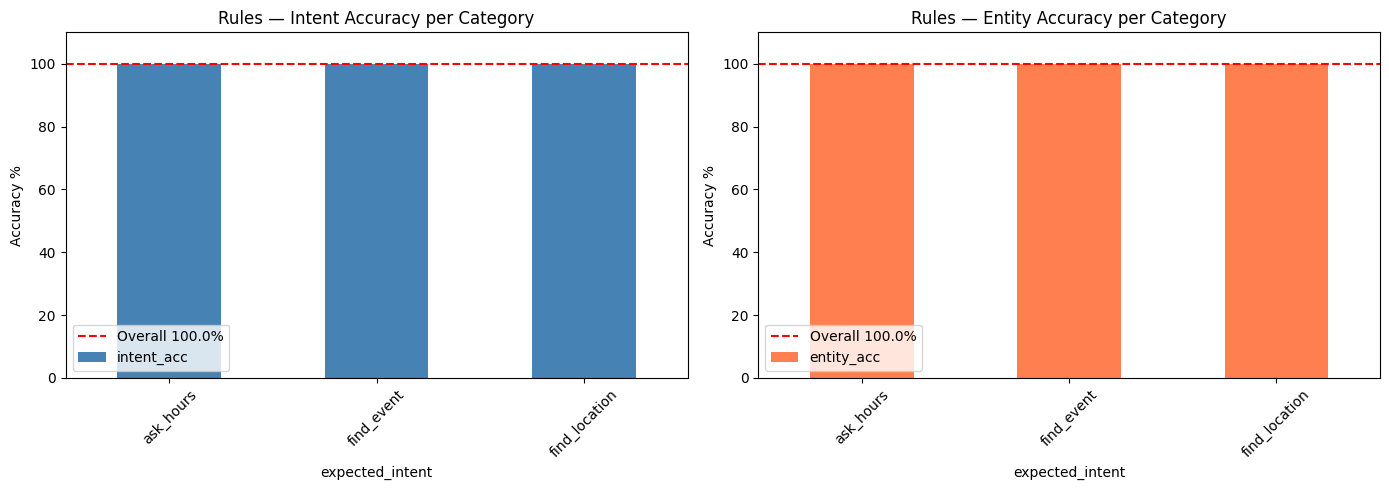

In [196]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

per_intent_rules.plot(
    x="expected_intent", y="intent_acc",
    kind="bar", ax=axes[0],
    title="Rules — Intent Accuracy per Category",
    color="steelblue", legend=False
)
axes[0].set_ylabel("Accuracy %")
axes[0].set_ylim(0, 110)
axes[0].axhline(y=intent_correct/total*100, color="red", linestyle="--",
                label=f"Overall {intent_correct/total*100:.1f}%")
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

per_intent_rules.plot(
    x="expected_intent", y="entity_acc",
    kind="bar", ax=axes[1],
    title="Rules — Entity Accuracy per Category",
    color="coral", legend=False
)
axes[1].set_ylabel("Accuracy %")
axes[1].set_ylim(0, 110)
axes[1].axhline(y=entity_correct/total*100, color="red", linestyle="--",
                label=f"Overall {entity_correct/total*100:.1f}%")
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [197]:
per_entity_rules = df_rules.groupby("expected_entity").agg(
    total          = ("intent_correct", "count"),
    intent_correct = ("intent_correct", "sum"),
    entity_correct = ("entity_correct", "sum"),
).reset_index()

per_entity_rules["intent_acc"] = (per_entity_rules["intent_correct"] / per_entity_rules["total"] * 100).round(1)
per_entity_rules["entity_acc"] = (per_entity_rules["entity_correct"] / per_entity_rules["total"] * 100).round(1)

print("=== Bottom 10 entities by entity accuracy (Rules) ===")
per_entity_rules.sort_values("entity_acc").head(10)

=== Bottom 10 entities by entity accuracy (Rules) ===


,expected_entity,total,intent_correct,entity_correct,intent_acc,entity_acc
0,AI & Machine Learning Lab (IT-L308),5,5,5,100.0,100.0
1,Admissions & Registry Office,7,7,7,100.0,100.0
2,Advanced Computing Lab (CSE-L410),5,5,5,100.0,100.0
3,Analog Electronics Lab (ENTC-L501),5,5,5,100.0,100.0
4,Analytical Chemistry Lab (CE-L208),5,5,5,100.0,100.0
5,Antenna & Microwave Lab (ENTC-L505),5,5,5,100.0,100.0
6,Automotive Lab (ME-L106),5,5,5,100.0,100.0
7,CAD & GIS Lab (CVL-L709),5,5,5,100.0,100.0
8,CAD/CAM Lab (ME-L103),5,5,5,100.0,100.0
9,Campus Coffee Shop,7,7,7,100.0,100.0


In [1]:
from pathlib import Path

RULES_DIR = Path(r"E:\Rohanta_AI_workbook\campus_chatbot\models\rules_model")
RULES_DIR.mkdir(parents=True, exist_ok=True)

rules_code = r'''# Rule base intent and entity classifier
import re
import json

INTENT_PATTERNS = {
    "find_location": [
        r"\bwhere\b", r"\blocation\b", r"\bdirections?\b",
        r"\bhow (do i|to) (get|reach|find|go)\b",
        r"\bfind\b", r"\bnavigate\b", r"\broom\b", r"\bfloor\b", r"\bbuilding\b",
    ],
    "opening_hours": [
        r"\bopen(ing)?\b", r"\bclos(e|ing|ed)\b", r"\bhours?\b",
        r"\btime\b", r"\bwhen\b", r"\bschedule\b", r"\btiming\b",
        r"\bopen on\b",
    ],
    "events": [
        r"\bevents?\b", r"\bworkshops?\b", r"\bseminars?\b",
        r"\bfestival\b", r"\bupcoming\b", r"\bhappening\b",
        r"\bcompetitions?\b", r"\bhackathon\b", r"\bfairs?\b",
        r"\bactivit(y|ies)\b", r"\bon at\b", r"\banything on\b",
        r"\bscheduled\b", r"\bexhibition\b", r"\bexpo\b",
        r"\bare there any\b",
    ],
    "description": [
        r"\bwhat is\b", r"\btell me about\b", r"\bdescribe\b",
        r"\bfacilities?\b", r"\bservices?\b", r"\bdetails?\b",
    ],
    "navigation": [
        r"\bfrom\b.+\bto\b", r"\bgo from\b", r"\broute from\b",
    ],
}

CATEGORY_KEYWORDS = {
    "library":        ["library", "books", "reading"],
    "cafeteria":      ["cafeteria", "canteen", "food", "eat", "meal"],
    "gym":            ["gym", "fitness", "sports", "yoga", "workout"],
    "it_lab":         ["it lab", "computer lab", "pc"],
    "department":     ["department", "dept"],
    "hod_office":     ["hod", "head of department"],
    "auditorium":     ["auditorium"],
    "medical_center": ["medical", "health", "clinic", "doctor"],
    "career_center":  ["career", "job", "placement"],
    "student_union":  ["student union", "union", "lounge"],
    "admin_office":   ["admission", "registry", "enrollment"],
    "lab":            ["lab", "laboratory"],
    "classroom":      ["classroom"],
    "seminar_room":   ["seminar room", "seminar"],
    "printing_room":  ["print", "photocopy"],
    "security_office":["security", "guard"],
}

ENTITY_MAP = {
    "library":         ["library", "books", "study desks", "place to study", "reading"],
    "cafeteria":       ["cafeteria", "canteen", "food", "eat", "meal", "dining area", "hungry"],
    "coffee shop":     ["coffee", "cafe", "hot drink", "coffee shop"],
    "student union":   ["student union", "su", "socialise", "social area", "student lounge"],
    "gym":             ["gym", "fitness", "sports centre", "exercise", "run", "workout", "sports"],
    "it lab":          ["it lab", "computer lab", "pc", "use a computer", "computer room"],
    "printing":        ["print", "printing room", "photocopy"],
    "admissions":      ["admissions", "registry", "student id", "registration", "enrollment", "dissertation"],
    "career":          ["career centre", "career services", "career advice", "cv help",
                        "cv workshop", "job listings", "careers and employability",
                        "career fair", "career events", "employability"],
    "medical":         ["medical", "doctor", "health centre", "unwell", "clinic", "health"],
    "auditorium":      ["auditorium", "main hall", "graduation"],
    "security":        ["security", "lost item", "campus security", "guard"],
    "research lab":    ["research lab", "innovation centre", "hackathon", "innovation", "research events"],
    "garden":          ["garden", "outdoor", "outside", "benches"],
    "accommodation":   ["accommodation", "housing", "student housing"],
    "engineering":     ["engineering block", "engineering college", "engineering building",
                        "engineering entrance", "engineering fest", "project exhibition",
                        "industry interaction", "final year project"],
    "department":      ["department", "dept"],
    "hod office":      ["hod", "head of department"],
    "seminar room":    ["seminar room", "seminar"],
    "classroom":       ["classroom"],
    "lecture hall":    ["lecture hall", "lecture theatre", "lecture hall a", "main lecture"],
}

OFFICIAL_ENTITY_NAME = {
    "library":       "Main Library",
    "cafeteria":     "Main Cafeteria",
    "coffee shop":   "Campus Coffee Shop",
    "student union": "Student Union",
    "gym":           "Sports & Fitness Centre",
    "it lab":        "IT & Computer Lab",
    "printing":      "Printing & Stationery Centre",
    "admissions":    "Admissions & Registry Office",
    "career":        "Career Services Centre",
    "medical":       "Medical & Counselling Centre",
    "auditorium":    "Main Auditorium",
    "security":      "Campus Security Office",
    "research lab":  "Research & Innovation Lab",
    "garden":        "Campus Garden & Outdoor Study Area",
    "accommodation": "Student Accommodation Office",
    "engineering":   "Engineering College - Main Block",
    "department":    "department",
    "hod office":    "hod_office",
    "seminar room":  "Seminar Room Block",
    "classroom":     "classroom",
}

KB_PATH = r"E:\Rohanta_AI_workbook\campus_chatbot\data\campus_kb.json"
with open(KB_PATH, encoding="utf-8") as f:
    _KB = json.load(f)

KB_ENTITY_MAP = {}
for entry in _KB:
    name = entry["name"]
    KB_ENTITY_MAP[name.lower()] = name
    if entry.get("room_number"):
        KB_ENTITY_MAP[entry["room_number"].lower()] = name

DEPT_TO_HOD = {
    "mechanical": "HOD Office ME-HOD101",
    "chemical":   "HOD Office CE-HOD202",
    "information technology": "HOD Office IT-HOD303",
    "computer":   "HOD Office CSE-HOD404",
    "cse":        "HOD Office CSE-HOD404",
    "entc":       "HOD Office ENTC-HOD505",
    "electrical": "HOD Office EE-HOD606",
    "civil":      "HOD Office CVL-HOD707",
}

DEPT_TO_TR = {
    "mechanical": "Teachers Room ME-TR101",
    "chemical":   "Teachers Room CE-TR202",
    "information technology": "Teachers Room IT-TR303",
    "computer":   "Teachers Room CSE-TR404",
    "cse":        "Teachers Room CSE-TR404",
    "entc":       "Teachers Room ENTC-TR505",
    "electrical": "Teachers Room EE-TR606",
    "civil":      "Teachers Room CVL-TR707",
}

DEPT_TO_NAME = {
    "mechanical engineering": "Mechanical Engineering Department",
    "chemical engineering":   "Chemical Engineering Department",
    "information technology": "Information Technology Department",
    "computer engineering":   "Computer Engineering Department",
    "entc":                   "Electronics & Telecommunication (ENTC) Department",
    "electrical engineering": "Electrical Engineering Department",
    "civil engineering":      "Civil Engineering Department",
}

NAV_SPLIT     = re.compile(r"\bfrom\s+(.+?)\s+to\s+(.+?)(?:\?|$)", re.IGNORECASE)
NAV_STOPWORDS = {"the","a","an","how","do","i","go","get","way","route","travel"}


def rules_classify_intent(query):
    q = query.lower()
    scores = {intent: 0 for intent in INTENT_PATTERNS}
    for intent, patterns in INTENT_PATTERNS.items():
        for pat in patterns:
            if re.search(pat, q):
                scores[intent] += 1
    best = max(scores, key=lambda k: scores[k])
    return best if scores[best] > 0 else "general"


def rules_category_hints(query):
    q = query.lower()
    return [cat for cat, kws in CATEGORY_KEYWORDS.items() if any(kw in q for kw in kws)]


def rules_nav_pair(query):
    m = NAV_SPLIT.search(query)
    if m:
        src = " ".join(w for w in m.group(1).split() if w.lower() not in NAV_STOPWORDS)
        dst = " ".join(w for w in m.group(2).split() if w.lower() not in NAV_STOPWORDS)
        if src and dst:
            return {"source": src, "destination": dst}
    return None


def rules_extract_entities(query):
    q = query.lower()
    found = []
    if any(kw in q for kw in ["teachers room", "faculty room", "staff room", "professor in"]):
        for dept_key, tr_name in DEPT_TO_TR.items():
            if dept_key in q:
                return [tr_name]
    if any(kw in q for kw in ["hod", "head of", "hod office", "hod room"]):
        for dept_key, hod_name in DEPT_TO_HOD.items():
            if dept_key in q:
                return [hod_name]
    for name_lower, official_name in KB_ENTITY_MAP.items():
        if name_lower in q:
            if official_name not in found:
                found.append(official_name)
    if found:
        return found
    for dept_kw, dept_name in DEPT_TO_NAME.items():
        if dept_kw in q:
            if dept_name not in found:
                found.append(dept_name)
    if found:
        return found
    for key, keywords in ENTITY_MAP.items():
        if any(kw in q for kw in keywords):
            official = OFFICIAL_ENTITY_NAME.get(key, key)
            if official not in found:
                found.append(official)
    return found


def extract_rules(query):
    intent   = rules_classify_intent(query)
    nav_pair = rules_nav_pair(query) if intent == "navigation" else None
    return {
        "intent":         intent,
        "entities":       rules_extract_entities(query),
        "category_hints": rules_category_hints(query),
        "nav_pair":       nav_pair,
        "raw_query":      query,
        "source":         "rules",
    }


def extract_with_fallback(query):
    return extract_rules(query)
'''

# Save to file
save_path = RULES_DIR / "rules_extractor.py"
with open(save_path, "w", encoding="utf-8") as f:
    f.write(rules_code)

print(f"Saved : {save_path}")
print(f"Size  : {save_path.stat().st_size} bytes")

# Verify it imports correctly
import importlib.util
spec   = importlib.util.spec_from_file_location("rules_extractor", save_path)
module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(module)

result = module.extract_rules("Where is the IT lab?")
print(f"\nVerify import:")
print(f"  Query  : Where is the IT lab?")
print(f"  Intent : {result['intent']}")
print(f"  Source : {result['source']}")

Saved : E:\Rohanta_AI_workbook\campus_chatbot\models\rules_model\rules_extractor.py
Size  : 9346 bytes

Verify import:
  Query  : Where is the IT lab?
  Intent : find_location
  Source : rules


In [199]:
# Spacy Model

In [1]:
import spacy
print("spaCy version:", spacy.__version__)
nlp = spacy.load("en_core_web_md")
print("Model loaded:", nlp.meta["name"])

spaCy version: 3.8.13
Model loaded: core_web_md


In [24]:
import spacy
import pandas as pd
import json
import random
from pathlib import Path
from spacy.tokens import DocBin
from spacy.util import minibatch, compounding
from sklearn.model_selection import train_test_split

FAQ_PATH = r"E:\Rohanta_AI_workbook\campus_chatbot\data\faq.csv"
KB_PATH  = r"E:\Rohanta_AI_workbook\campus_chatbot\data\campus_kb.json"
OUTPUT_DIR = Path(r"E:\Rohanta_AI_workbook\campus_chatbot\models\campus_spacy")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(FAQ_PATH)
with open(KB_PATH, encoding="utf-8") as f:
    kb = json.load(f)

print(f"FAQ rows   : {len(df)}")
print(f"KB entries : {len(kb)}")
print(f"Intents    : {df['intent'].unique().tolist()}")

FAQ rows   : 734
KB entries : 154
Intents    : ['find_location', 'ask_hours', 'find_event']


In [25]:
# Build lookup: entity name → official name (lowercase → original)
entity_lookup = {}
for entry in kb:
    name = entry["name"]
    entity_lookup[name.lower()] = name

print(f"Total entities in lookup: {len(entity_lookup)}")
ENTITY_SYNONYMS = {
    "IT & Computer Lab":                    ["it lab", "computer lab", "computer room"],
    "Sports & Fitness Centre":              ["gym", "fitness centre", "sports centre"],
    "Main Library":                         ["library", "main library"],
    "Main Cafeteria":                       ["cafeteria", "canteen"],
    "Campus Coffee Shop":                   ["coffee shop", "cafe"],
    "Student Union":                        ["student union", "su"],
    "Mechanical Engineering Department":    ["mechanical engineering", "mechanical dept", "me dept"],
    "Civil Engineering Department":         ["civil engineering", "civil dept"],
    "Chemical Engineering Department":      ["chemical engineering", "chemical dept"],
    "Computer Engineering Department":      ["computer engineering", "cse dept"],
    "Electrical Engineering Department":    ["electrical engineering", "ee dept"],
    "Information Technology Department":    ["information technology", "it dept"],
    "Electronics & Telecommunication (ENTC) Department": ["entc", "electronics dept"],
    "Medical & Counselling Centre":         ["medical centre", "health centre", "clinic"],
    "Career Services Centre":               ["career centre", "careers"],
    "Admissions & Registry Office":         ["admissions", "registry"],
    "Printing & Stationery Centre":         ["printing room", "print centre"],
    "Campus Security Office":               ["security office", "security"],
    "Research & Innovation Lab":            ["research lab", "innovation lab"],
}

def find_entity_spans(text: str, entity_name: str) -> list:
    spans = []
    text_lower = text.lower()

    # Search for official name
    search = entity_name.lower()
    start = 0
    while True:
        idx = text_lower.find(search, start)
        if idx == -1:
            break
        spans.append((idx, idx + len(search), "CAMPUS_LOCATION"))
        start = idx + 1

    # Search for synonyms
    for synonym in ENTITY_SYNONYMS.get(entity_name, []):
        start = 0
        while True:
            idx = text_lower.find(synonym, start)
            if idx == -1:
                break
            spans.append((idx, idx + len(synonym), "CAMPUS_LOCATION"))
            start = idx + 1

    # Deduplicate overlapping spans — keep longest
    spans = sorted(set(spans), key=lambda x: x[0])
    return spans

Total entities in lookup: 154


In [39]:
training_data = []

for _, row in df.iterrows():
    query       = row["query"]
    intent      = row["intent"]
    entity_name = row["entity"]

    # Find entity spans in query
    spans = find_entity_spans(query, entity_name)

    training_data.append({
        "text":   query,
        "intent": intent,
        "spans":  spans,
    })

# Check coverage
has_spans  = sum(1 for d in training_data if d["spans"])
no_spans   = sum(1 for d in training_data if not d["spans"])
print(f"Total samples    : {len(training_data)}")
print(f"With entity spans: {has_spans}")
print(f"Without spans    : {no_spans}")

# Show a few examples
for d in training_data[:5]:
    print(f"\nText  : {d['text']}")
    print(f"Intent: {d['intent']}")
    print(f"Spans : {d['spans']}")

extra_samples = [
    {"text": "ME dept location?",           "intent": "find_location", "spans": [(0, 7, "CAMPUS_LOCATION")]},
    {"text": "mechnical engineering dept",   "intent": "find_location", "spans": [(0, 25, "CAMPUS_LOCATION")]},
    {"text": "civil dept where",             "intent": "find_location", "spans": [(0, 9, "CAMPUS_LOCATION")]},
    {"text": "CSE dept floor",               "intent": "find_location", "spans": [(0, 8, "CAMPUS_LOCATION")]},
    {"text": "EE dept location",             "intent": "find_location", "spans": [(0, 7, "CAMPUS_LOCATION")]},
    {"text": "IT dept where",                "intent": "find_location", "spans": [(0, 7, "CAMPUS_LOCATION")]},
    {"text": "ENTC dept floor",              "intent": "find_location", "spans": [(0, 9, "CAMPUS_LOCATION")]},
    {"text": "mechnical dept",               "intent": "find_location", "spans": [(0, 13, "CAMPUS_LOCATION")]},
    {"text": "civl engineering where",       "intent": "find_location", "spans": [(0, 16, "CAMPUS_LOCATION")]},
    {"text": "compter engineering location", "intent": "find_location", "spans": [(0, 20, "CAMPUS_LOCATION")]},
     # find_location — abbreviations and typos
    {"text": "ME dept location?",           "intent": "find_location", "spans": [(0, 7,  "CAMPUS_LOCATION")]},
    {"text": "mechnical engineering dept",   "intent": "find_location", "spans": [(0, 25, "CAMPUS_LOCATION")]},
    {"text": "civil dept where",             "intent": "find_location", "spans": [(0, 9,  "CAMPUS_LOCATION")]},
    {"text": "CSE dept floor",               "intent": "find_location", "spans": [(0, 8,  "CAMPUS_LOCATION")]},
    {"text": "EE dept location",             "intent": "find_location", "spans": [(0, 7,  "CAMPUS_LOCATION")]},
    {"text": "IT dept where",                "intent": "find_location", "spans": [(0, 7,  "CAMPUS_LOCATION")]},
    {"text": "ENTC dept floor",              "intent": "find_location", "spans": [(0, 9,  "CAMPUS_LOCATION")]},
    {"text": "mechnical dept",               "intent": "find_location", "spans": [(0, 13, "CAMPUS_LOCATION")]},
    {"text": "civl engineering where",       "intent": "find_location", "spans": [(0, 16, "CAMPUS_LOCATION")]},
    {"text": "compter engineering location", "intent": "find_location", "spans": [(0, 20, "CAMPUS_LOCATION")]},

    # ask_hours — to balance distribution
    {"text": "ME dept open on Saturday?",    "intent": "ask_hours",     "spans": [(0, 7,  "CAMPUS_LOCATION")]},
    {"text": "gym timings on sunday",        "intent": "ask_hours",     "spans": [(0, 3,  "CAMPUS_LOCATION")]},
    {"text": "library kab khulta hai",       "intent": "ask_hours",     "spans": [(0, 7,  "CAMPUS_LOCATION")]},
    {"text": "canteen close time",           "intent": "ask_hours",     "spans": [(0, 7,  "CAMPUS_LOCATION")]},
    {"text": "IT dept hours saturday",       "intent": "ask_hours",     "spans": [(0, 7,  "CAMPUS_LOCATION")]},

    # find_event — to balance distribution
    {"text": "ME dept any events this week", "intent": "find_event",    "spans": [(0, 7,  "CAMPUS_LOCATION")]},
    {"text": "gym competitions coming up",   "intent": "find_event",    "spans": [(0, 3,  "CAMPUS_LOCATION")]},
    {"text": "library workshops this week",  "intent": "find_event",    "spans": [(0, 7,  "CAMPUS_LOCATION")]},
    {"text": "canteen any events",           "intent": "find_event",    "spans": [(0, 7,  "CAMPUS_LOCATION")]},
    {"text": "IT dept hackathon coming",     "intent": "find_event",    "spans": [(0, 7,  "CAMPUS_LOCATION")]},

]

training_data.extend(extra_samples)
print(f"Total after augmentation: {len(training_data)}")

Total samples    : 734
With entity spans: 519
Without spans    : 215

Text  : Where is the library?
Intent: find_location
Spans : [(13, 20, 'CAMPUS_LOCATION')]

Text  : How do I get to the main library?
Intent: find_location
Spans : [(20, 32, 'CAMPUS_LOCATION'), (25, 32, 'CAMPUS_LOCATION')]

Text  : Can you show me where the library is?
Intent: find_location
Spans : [(26, 33, 'CAMPUS_LOCATION')]

Text  : I need to find a place to study with books
Intent: find_location
Spans : []

Text  : Where are the books and study desks?
Intent: find_location
Spans : []
Total after augmentation: 764


In [40]:
random.seed(42)
random.shuffle(training_data)

train_data, dev_data = train_test_split(training_data, test_size=0.2, random_state=42)

print(f"Train samples : {len(train_data)}")
print(f"Dev samples   : {len(dev_data)}")

# Intent distribution in train
from collections import Counter
train_intents = Counter(d["intent"] for d in train_data)
dev_intents   = Counter(d["intent"] for d in dev_data)
print(f"\nTrain intents : {dict(train_intents)}")
print(f"Dev intents   : {dict(dev_intents)}")

Train samples : 611
Dev samples   : 153

Train intents : {'ask_hours': 153, 'find_location': 430, 'find_event': 28}
Dev intents   : {'find_location': 107, 'find_event': 10, 'ask_hours': 36}


In [41]:
def make_docbin(data: list, nlp) -> DocBin:
    db = DocBin()
    skipped = 0

    for item in data:
        doc = nlp.make_doc(item["text"])

        # --- textcat labels ---
        doc.cats = {
            "find_location": 1.0 if item["intent"] == "find_location" else 0.0,
            "ask_hours":     1.0 if item["intent"] == "ask_hours"     else 0.0,
            "find_event":    1.0 if item["intent"] == "find_event"    else 0.0,
        }

        # --- NER spans ---
        ents = []
        for start_char, end_char, label in item["spans"]:
            span = doc.char_span(start_char, end_char, label=label)
            if span is not None:
                ents.append(span)

        try:
            doc.ents = ents
        except Exception as e:
            skipped += 1
            doc.ents = []

        db.add(doc)

    print(f"Skipped (overlapping spans): {skipped}")
    return db

nlp_blank = spacy.load("en_core_web_md")

train_db = make_docbin(train_data, nlp_blank)
dev_db   = make_docbin(dev_data,   nlp_blank)

train_db.to_disk(OUTPUT_DIR / "train.spacy")
dev_db.to_disk(OUTPUT_DIR  / "dev.spacy")

print(f"Saved train.spacy and dev.spacy to {OUTPUT_DIR}")

Skipped (overlapping spans): 17
Skipped (overlapping spans): 3
Saved train.spacy and dev.spacy to E:\Rohanta_AI_workbook\campus_chatbot\models\campus_spacy


In [42]:
config_text = """
[paths]
train = null
dev = null

[system]
gpu_allocator = null

[nlp]
lang = "en"
pipeline = ["tok2vec","ner","textcat"]
batch_size = 1000

[components]

[components.tok2vec]
source = "en_core_web_md"

[components.ner]
source = "en_core_web_md"

[components.textcat]
factory = "textcat"

[components.textcat.model]
@architectures = "spacy.TextCatBOW.v3"
exclusive_classes = true
ngram_size = 1
no_output_layer = false

[corpora]

[corpora.train]
@readers = "spacy.Corpus.v1"
path = ${paths.train}
max_length = 0

[corpora.dev]
@readers = "spacy.Corpus.v1"
path = ${paths.dev}
max_length = 0

[training]
dev_corpus = "corpora.dev"
train_corpus = "corpora.train"
seed = 42
gpu_allocator = null
dropout = 0.1
accumulate_gradient = 1
patience = 1600
max_epochs = 0
max_steps = 2000
eval_frequency = 200
frozen_components = []
annotating_components = []
before_to_disk = null

[training.batcher]
@batchers = "spacy.batch_by_words.v1"
discard_oversize = false
tolerance = 0.2

[training.batcher.size]
@schedules = "compounding.v1"
start = 100
stop = 1000
compound = 1.001

[training.optimizer]
@optimizers = "Adam.v1"
beta1 = 0.9
beta2 = 0.999
L2_is_weight_decay = true
L2 = 0.01
grad_clip = 1.0
use_averages = false
eps = 1e-8

[training.optimizer.learn_rate]
@schedules = "warmup_linear.v1"
warmup_steps = 250
total_steps = 2000
initial_rate = 5e-4

[training.score_weights]
ents_f = 0.5
cats_macro_f = 0.5

[pretraining]

[initialize]
vectors = "en_core_web_md"
init_tok2vec = null

[initialize.components]
"""

config_path = OUTPUT_DIR / "config.cfg"
with open(config_path, "w") as f:
    f.write(config_text.strip())

print(f"Config saved to {config_path}")

# Verify no read_labels in config
content = open(config_path).read()
print("read_labels present:", "read_labels" in content)

Config saved to E:\Rohanta_AI_workbook\campus_chatbot\models\campus_spacy\config.cfg
read_labels present: False


In [43]:
import subprocess
import sys

train_path  = str(OUTPUT_DIR / "train.spacy")
dev_path    = str(OUTPUT_DIR / "dev.spacy")
config_path = str(OUTPUT_DIR / "config.cfg")
output_path = str(OUTPUT_DIR / "output")

# Use the same Python that's running this notebook
python_exe = sys.executable
print(f"Using Python: {python_exe}")

cmd = [
    python_exe, "-m", "spacy", "train",
    config_path,
    "--output", output_path,
    "--paths.train", train_path,
    "--paths.dev",   dev_path,
    "--gpu-id", "-1",
]

print("Starting training...")
result = subprocess.run(cmd, capture_output=True, text=True)

print("STDOUT:")
print(result.stdout)
print("\nSTDERR:")
print(result.stderr)
print("\nReturn code:", result.returncode)

Using Python: e:\Rohanta_AI_workbook\campus_chatbot\venv\Scripts\python.exe
Starting training...
STDOUT:
â„¹ Saving to output directory:
E:\Rohanta_AI_workbook\campus_chatbot\models\campus_spacy\output
â„¹ Using CPU

=========================== Initializing pipeline ===========================
âœ” Initialized pipeline

============================= Training pipeline =============================
â„¹ Pipeline: ['tok2vec', 'ner', 'textcat']
â„¹ Initial learn rate: 0.0
E    #       LOSS TOK2VEC  LOSS NER  LOSS TEXTCAT  ENTS_F  ENTS_P  ENTS_R  CATS_SCORE  CATS_MACRO_F  SCORE 
---  ------  ------------  --------  ------------  ------  ------  ------  ----------  ------------  ------
  0       0          0.00      9.58          0.22    0.00    0.00    0.00       27.44         27.44    0.21
  3     200          0.00   3112.07         37.65   75.86   81.91   70.64       81.33         81.33    0.80
  7     400          0.00    244.68         14.43   97.25   97.25   97.25       87.20         87.

In [44]:
import re
best_model_path = OUTPUT_DIR / "output" / "model-best"
nlp_trained = spacy.load(best_model_path)

test_queries = [
    "Where is the IT lab?",
    "Is the gym open on Sunday?",
    "What events are at the library?",
    "Where is Mechanical Engineering Department?",
    "mechnical eng department where?",
    "ME dept location?",
]

for q in test_queries:
    doc    = nlp_trained(q)
    intent = max(doc.cats, key=lambda k: doc.cats[k])
    conf   = doc.cats[intent]
    ents   = [(ent.text, ent.label_) for ent in doc.ents]

    # Clean trailing punctuation   ← add here
    clean_ents = [(re.sub(r'[?!.,]+$', '', e[0]).strip(), e[1]) for e in ents]

    print(f"\nQuery   : {q}")
    print(f"Intent  : {intent} ({conf:.2f})")
    print(f"Entities: {clean_ents}")   # ← use clean_ents here


Query   : Where is the IT lab?
Intent  : find_location (0.94)
Entities: [('IT lab', 'CAMPUS_LOCATION')]

Query   : Is the gym open on Sunday?
Intent  : ask_hours (0.94)
Entities: [('gym', 'CAMPUS_LOCATION')]

Query   : What events are at the library?
Intent  : find_event (0.82)
Entities: [('library', 'CAMPUS_LOCATION')]

Query   : Where is Mechanical Engineering Department?
Intent  : find_location (0.93)
Entities: [('Mechanical Engineering Department', 'CAMPUS_LOCATION')]

Query   : mechnical eng department where?
Intent  : find_location (0.85)
Entities: []

Query   : ME dept location?
Intent  : find_location (0.86)
Entities: [('ME dept', 'CAMPUS_LOCATION')]


In [45]:
# Final evaluation on dev set
from spacy.training import Example

dev_db_loaded = DocBin().from_disk(OUTPUT_DIR / "dev.spacy")
dev_docs      = list(dev_db_loaded.get_docs(nlp_trained.vocab))

examples = []
for doc in dev_docs:
    pred = nlp_trained(doc.text)
    examples.append(Example(pred, doc))

scores = nlp_trained.evaluate(examples)
print(f"NER F-score    : {scores['ents_f']:.3f}")
print(f"NER Precision  : {scores['ents_p']:.3f}")
print(f"NER Recall     : {scores['ents_r']:.3f}")
print(f"Textcat Macro F: {scores['cats_macro_f']:.3f}")
print(f"Overall Score  : {(scores['ents_f'] + scores['cats_macro_f']) / 2:.3f}")

NER F-score    : 0.986
NER Precision  : 0.973
NER Recall     : 1.000
Textcat Macro F: 0.988
Overall Score  : 0.987


In [46]:
import matplotlib.pyplot as plt
import numpy as np

# Training results from your log
steps = [0, 200, 400, 600, 800, 1000, 1200, 1400, 1600, 1800, 2000]

loss_ner     = [9.58, 3112.07, 244.68, 32.47, 4.75, 2.69, 1.31, 0.01, 0.01, 1.50, 1.11]
loss_textcat = [0.22, 37.65, 14.43, 4.48, 1.95, 1.19, 0.82, 0.64, 0.53, 0.46, 0.42]
ents_f       = [0.00, 75.86, 97.25, 98.64, 98.64, 98.64, 98.64, 98.64, 98.64, 98.64, 98.20]
cats_f       = [27.44, 81.33, 87.20, 96.56, 96.56, 98.76, 98.76, 98.76, 98.76, 98.76, 98.76]
score        = [0.21, 0.80, 0.90, 0.97, 0.97, 0.99, 0.99, 0.99, 0.99, 0.99, 0.99]

print("Training log loaded.")

Training log loaded.


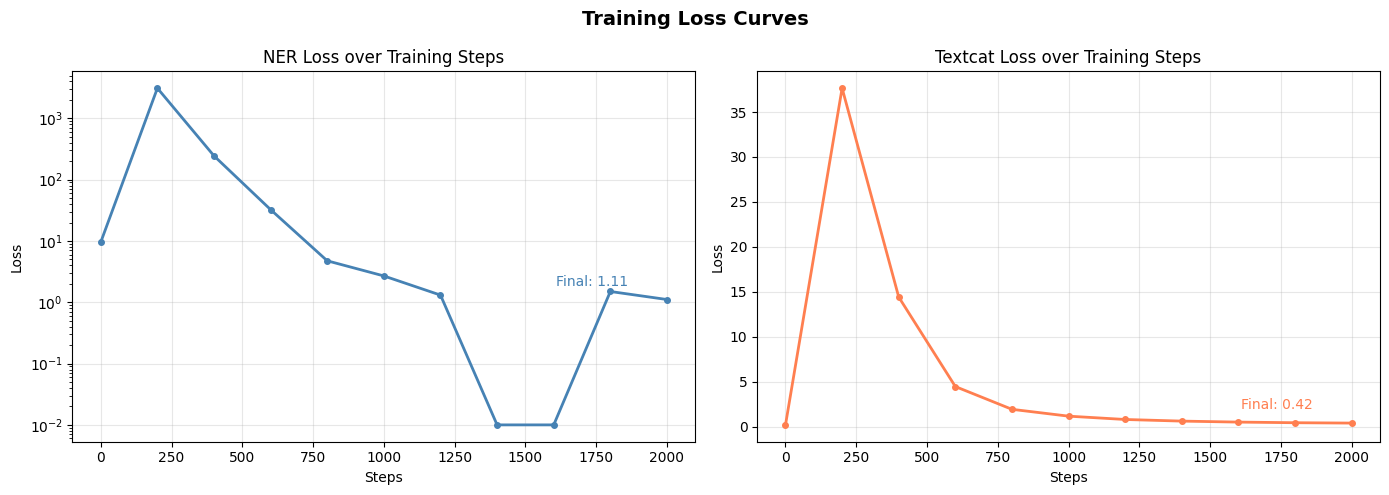

Saved: training_loss.png


In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(steps, loss_ner, color='steelblue', linewidth=2, marker='o', markersize=4)
axes[0].set_title("NER Loss over Training Steps")
axes[0].set_xlabel("Steps")
axes[0].set_ylabel("Loss")
axes[0].set_yscale("log")
axes[0].grid(True, alpha=0.3)
axes[0].annotate(f"Final: {loss_ner[-1]:.2f}", xy=(steps[-1], loss_ner[-1]),
                 xytext=(-80, 10), textcoords="offset points", color="steelblue")

axes[1].plot(steps, loss_textcat, color='coral', linewidth=2, marker='o', markersize=4)
axes[1].set_title("Textcat Loss over Training Steps")
axes[1].set_xlabel("Steps")
axes[1].set_ylabel("Loss")
axes[1].grid(True, alpha=0.3)
axes[1].annotate(f"Final: {loss_textcat[-1]:.2f}", xy=(steps[-1], loss_textcat[-1]),
                 xytext=(-80, 10), textcoords="offset points", color="coral")

plt.suptitle("Training Loss Curves", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("training_loss.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: training_loss.png")

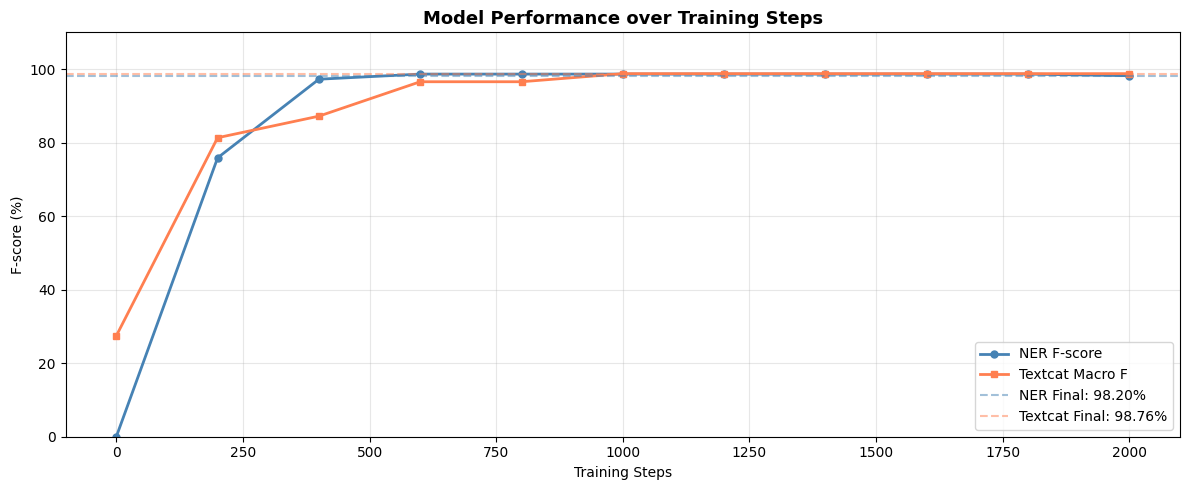

Saved: performance_convergence.png


In [48]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(steps, ents_f, color='steelblue', linewidth=2, marker='o', markersize=5, label='NER F-score')
ax.plot(steps, cats_f, color='coral',     linewidth=2, marker='s', markersize=5, label='Textcat Macro F')

ax.axhline(y=98.20, color='steelblue', linestyle='--', alpha=0.5, label=f'NER Final: 98.20%')
ax.axhline(y=98.76, color='coral',     linestyle='--', alpha=0.5, label=f'Textcat Final: 98.76%')

ax.set_title("Model Performance over Training Steps", fontsize=13, fontweight='bold')
ax.set_xlabel("Training Steps")
ax.set_ylabel("F-score (%)")
ax.set_ylim(0, 110)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("performance_convergence.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: performance_convergence.png")

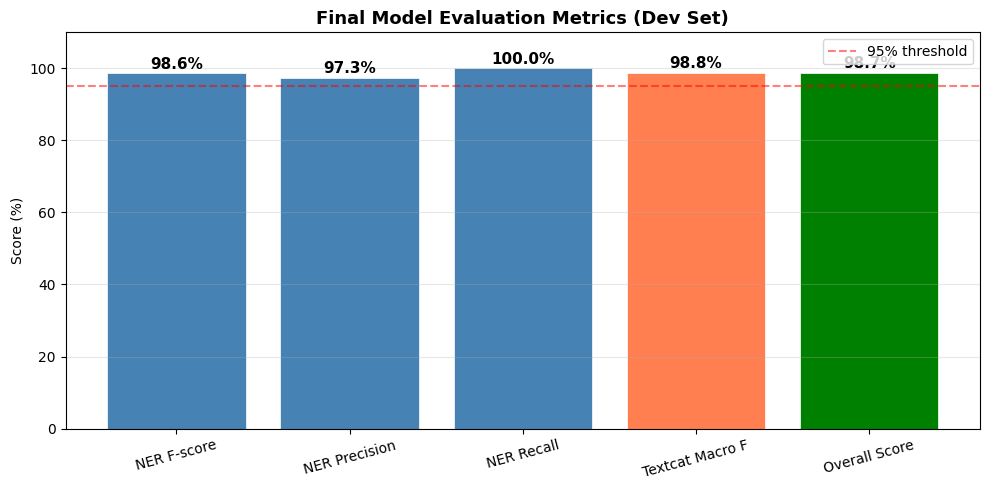

Saved: final_metrics.png


In [49]:
metrics = {
    'NER F-score':     0.986,
    'NER Precision':   0.973,
    'NER Recall':      1.000,
    'Textcat Macro F': 0.988,
    'Overall Score':   0.987,
}

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(metrics.keys(), [v * 100 for v in metrics.values()],
              color=['steelblue','steelblue','steelblue','coral','green'],
              edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, metrics.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val*100:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title("Final Model Evaluation Metrics (Dev Set)", fontsize=13, fontweight='bold')
ax.set_ylabel("Score (%)")
ax.set_ylim(0, 110)
ax.axhline(y=95, color='red', linestyle='--', alpha=0.5, label='95% threshold')
ax.legend()
ax.tick_params(axis='x', rotation=15)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("final_metrics.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: final_metrics.png")

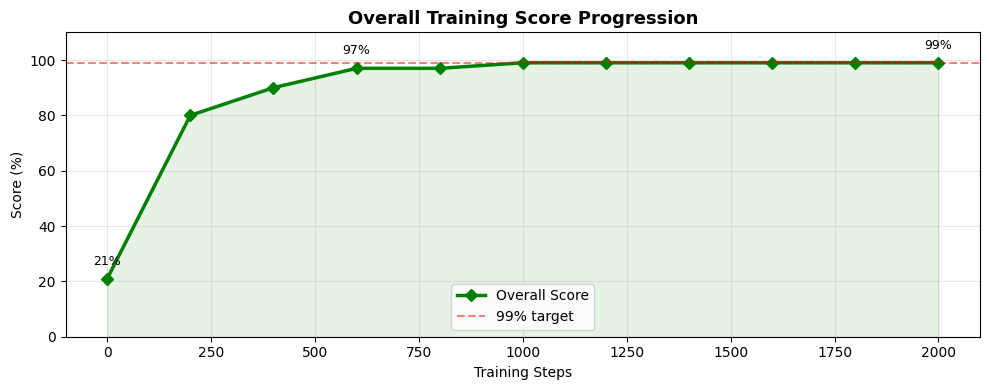

Saved: overall_score.png


In [50]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(steps, [s * 100 for s in score], color='green', linewidth=2.5,
        marker='D', markersize=6, label='Overall Score')
ax.fill_between(steps, [s * 100 for s in score], alpha=0.1, color='green')

ax.axhline(y=99, color='red', linestyle='--', alpha=0.5, label='99% target')

ax.set_title("Overall Training Score Progression", fontsize=13, fontweight='bold')
ax.set_xlabel("Training Steps")
ax.set_ylabel("Score (%)")
ax.set_ylim(0, 110)
ax.legend()
ax.grid(True, alpha=0.3)

for i, (s, v) in enumerate(zip(steps, score)):
    if i in [0, 3, len(steps)-1]:
        ax.annotate(f'{v*100:.0f}%', xy=(s, v*100),
                    xytext=(0, 10), textcoords="offset points",
                    ha='center', fontsize=9)

plt.tight_layout()
plt.savefig("overall_score.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: overall_score.png")

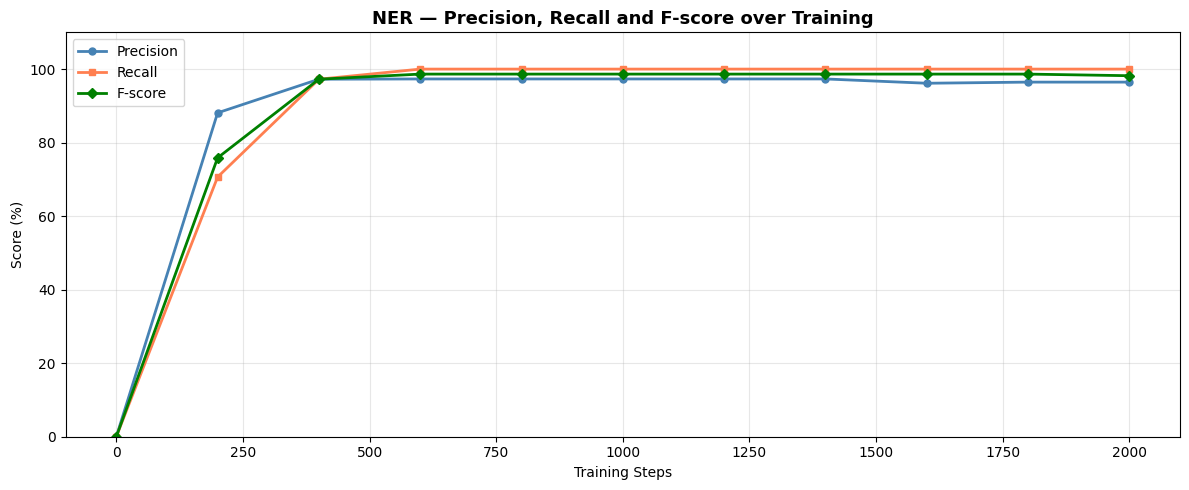

Saved: ner_prf.png


In [51]:
precision = [0, 88.10, 97.25, 97.32, 97.32, 97.32, 97.32, 97.32, 96.15, 96.46, 96.46]
recall    = [0, 70.64, 97.25, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0]

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(steps, precision, color='steelblue', linewidth=2, marker='o', markersize=5, label='Precision')
ax.plot(steps, recall,    color='coral',     linewidth=2, marker='s', markersize=5, label='Recall')
ax.plot(steps, ents_f,    color='green',     linewidth=2, marker='D', markersize=5, label='F-score')

ax.set_title("NER — Precision, Recall and F-score over Training", fontsize=13, fontweight='bold')
ax.set_xlabel("Training Steps")
ax.set_ylabel("Score (%)")
ax.set_ylim(0, 110)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("ner_prf.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ner_prf.png")

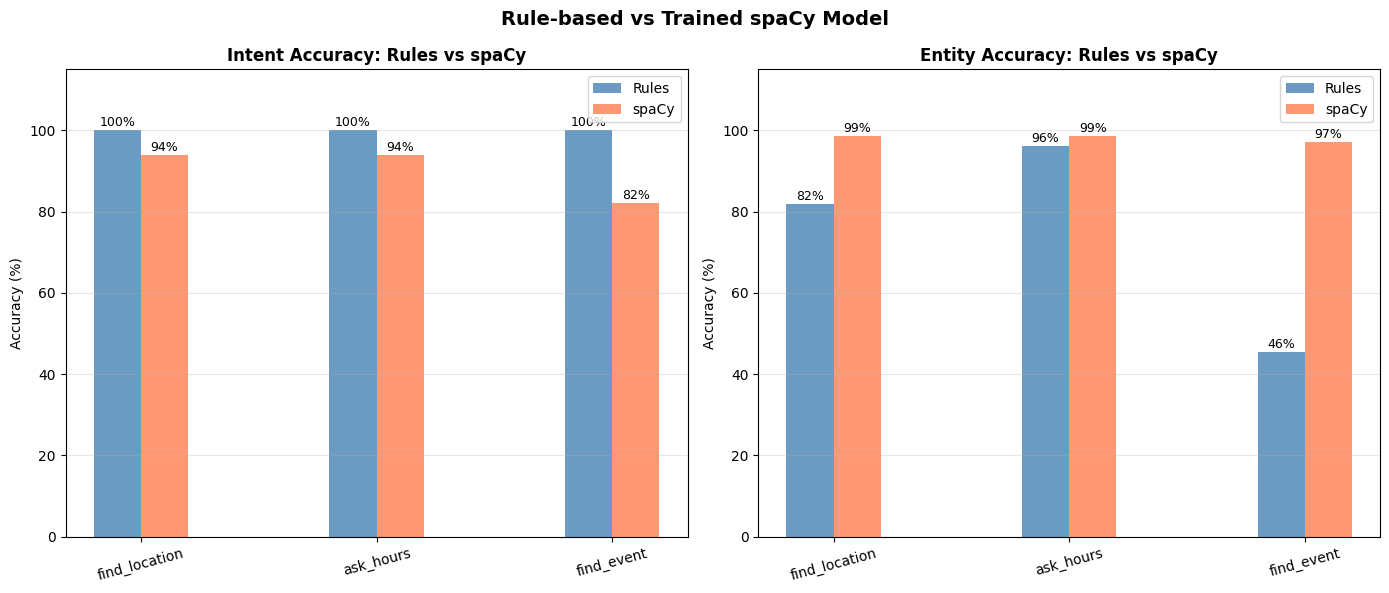

Saved: rules_vs_spacy.png


In [52]:
categories   = ['find_location', 'ask_hours', 'find_event']
rules_intent = [100.0, 100.0, 100.0]
spacy_intent = [94.0,  94.0,  82.0]
rules_entity = [81.8,  96.2,  45.5]
spacy_entity = [98.6,  98.6,  97.0]

x     = np.arange(len(categories))
width = 0.2

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Intent comparison
axes[0].bar(x - width/2, rules_intent, width, label='Rules',  color='steelblue', alpha=0.8)
axes[0].bar(x + width/2, spacy_intent, width, label='spaCy',  color='coral',     alpha=0.8)
axes[0].set_title("Intent Accuracy: Rules vs spaCy", fontsize=12, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(categories, rotation=15)
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_ylim(0, 115)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
for i, (r, s) in enumerate(zip(rules_intent, spacy_intent)):
    axes[0].text(i - width/2, r + 1, f'{r:.0f}%', ha='center', fontsize=9)
    axes[0].text(i + width/2, s + 1, f'{s:.0f}%', ha='center', fontsize=9)

# Entity comparison
axes[1].bar(x - width/2, rules_entity, width, label='Rules',  color='steelblue', alpha=0.8)
axes[1].bar(x + width/2, spacy_entity, width, label='spaCy',  color='coral',     alpha=0.8)
axes[1].set_title("Entity Accuracy: Rules vs spaCy", fontsize=12, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(categories, rotation=15)
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_ylim(0, 115)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)
for i, (r, s) in enumerate(zip(rules_entity, spacy_entity)):
    axes[1].text(i - width/2, r + 1, f'{r:.0f}%', ha='center', fontsize=9)
    axes[1].text(i + width/2, s + 1, f'{s:.0f}%', ha='center', fontsize=9)

plt.suptitle("Rule-based vs Trained spaCy Model", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("rules_vs_spacy.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: rules_vs_spacy.png")

In [53]:
# Distilbrt

In [56]:
import torch
import transformers
print("torch:", torch.__version__)
print("transformers:", transformers.__version__)

e:\Rohanta_AI_workbook\campus_chatbot\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch: 2.12.0+cpu
transformers: 5.9.0


In [58]:
import torch
import pandas as pd
import numpy as np
import json
from pathlib import Path
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

FAQ_PATH   = r"E:\Rohanta_AI_workbook\campus_chatbot\data\faq.csv"
MODEL_DIR  = Path(r"E:\Rohanta_AI_workbook\campus_chatbot\models\distilbert_campus")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_NAME = "distilbert-base-uncased"
MAX_LEN    = 64
BATCH_SIZE = 32
EPOCHS     = 5
LR         = 2e-5

print(f"Device : {DEVICE}")
print(f"PyTorch: {torch.__version__}")

Device : cpu
PyTorch: 2.12.0+cpu


In [59]:
# Load FAQ CSV
df_faq = pd.read_csv(FAQ_PATH)

# Ground truth queries
ground_truth = [
    {"query": "Where is the main library?",                           "intent": "find_location"},
    {"query": "Where is the cafeteria?",                              "intent": "find_location"},
    {"query": "How do I find the IT lab?",                            "intent": "find_location"},
    {"query": "Where is the gym on campus?",                          "intent": "find_location"},
    {"query": "Where is the Student Union?",                          "intent": "find_location"},
    {"query": "How do I get to the admissions office?",               "intent": "find_location"},
    {"query": "Where is the career services centre?",                 "intent": "find_location"},
    {"query": "Where can I find the medical centre?",                 "intent": "find_location"},
    {"query": "Where is the main auditorium?",                        "intent": "find_location"},
    {"query": "Where is the printing centre?",                        "intent": "find_location"},
    {"query": "Where is the Mechanical Engineering Department?",      "intent": "find_location"},
    {"query": "How do I reach the Civil Engineering Department?",     "intent": "find_location"},
    {"query": "Where is the HOD office for civil engineering?",       "intent": "find_location"},
    {"query": "Where is the HOD office for mechanical engineering?",  "intent": "find_location"},
    {"query": "Where is the campus security office?",                 "intent": "find_location"},
    {"query": "What time does the library open on Monday?",           "intent": "ask_hours"},
    {"query": "Is the library open on Sunday?",                       "intent": "ask_hours"},
    {"query": "What are the cafeteria opening hours on Saturday?",    "intent": "ask_hours"},
    {"query": "When does the gym open on weekdays?",                  "intent": "ask_hours"},
    {"query": "What time does the Student Union close on Friday?",    "intent": "ask_hours"},
    {"query": "Is the admissions office open on Saturday?",           "intent": "ask_hours"},
    {"query": "What are the IT lab hours on Saturday?",               "intent": "ask_hours"},
    {"query": "When does the career services centre close on Friday?","intent": "ask_hours"},
    {"query": "What time does the medical centre open?",              "intent": "ask_hours"},
    {"query": "Is the gym open on Sunday?",                           "intent": "ask_hours"},
    {"query": "What time does the printing centre close on Saturday?","intent": "ask_hours"},
    {"query": "When does the cafeteria open in the morning?",         "intent": "ask_hours"},
    {"query": "What events are happening at the library?",            "intent": "find_event"},
    {"query": "Are there any events at the Student Union?",           "intent": "find_event"},
    {"query": "What is happening at the IT lab?",                     "intent": "find_event"},
    {"query": "Are there any events at the cafeteria?",               "intent": "find_event"},
    {"query": "What events are scheduled at the gym?",                "intent": "find_event"},
    {"query": "What is happening at the career centre?",              "intent": "find_event"},
    {"query": "What events are at the auditorium?",                   "intent": "find_event"},
    {"query": "What is happening at the medical centre this month?",  "intent": "find_event"},
    {"query": "Tell me about the main library.",                      "intent": "find_location"},
    {"query": "What facilities does the gym have?",                   "intent": "find_location"},
    {"query": "What is the Student Union?",                           "intent": "find_location"},
    {"query": "Tell me about the IT lab.",                            "intent": "find_location"},
    {"query": "What services does the career centre provide?",        "intent": "find_location"},
    {"query": "How do I go from the library to the cafeteria?",      "intent": "find_location"},
    {"query": "Route from civil department to mechanical department.", "intent": "find_location"},
    {"query": "How do I go from the gym to the IT lab?",             "intent": "find_location"},
    {"query": "Go from Student Union to the library.",                "intent": "find_location"},
    {"query": "From the cafeteria to the admissions office.",         "intent": "find_location"},
    {"query": "How to go from mechanical department to civil department?","intent": "find_location"},
    {"query": "Route from IT lab to the gym.",                        "intent": "find_location"},
    {"query": "From medical centre to career services.",              "intent": "find_location"},
    {"query": "How many departments are there in the college?",       "intent": "find_location"},
    {"query": "List all labs in the engineering block.",              "intent": "find_location"},
    {"query": "Which events are happening this week?",                "intent": "find_event"},
    {"query": "Are there any free events on campus?",                 "intent": "find_event"},
    {"query": "What events are happening in June?",                   "intent": "find_event"},
    {"query": "Are there any workshops I can attend?",                "intent": "find_event"},
    {"query": "What events are happening tomorrow?",                  "intent": "find_event"},
    {"query": "Are there any tech or coding events?",                 "intent": "find_event"},
    {"query": "What events are good for new students?",               "intent": "find_event"},
    {"query": "Is there anything happening at the engineering block?","intent": "find_event"},
    {"query": "What morning events are available this week?",         "intent": "find_event"},
    {"query": "Are there any competitions on campus?",                "intent": "find_event"},
]

df_gt = pd.DataFrame(ground_truth).rename(columns={"query": "query", "intent": "intent"})
df_gt["entity"] = "unknown"

# Combine
df_all = pd.concat([
    df_faq[["query", "intent"]],
    df_gt[["query", "intent"]]
], ignore_index=True)

print(f"FAQ samples       : {len(df_faq)}")
print(f"Ground truth      : {len(df_gt)}")
print(f"Total combined    : {len(df_all)}")
print(f"\nIntent distribution:\n{df_all['intent'].value_counts()}")

FAQ samples       : 734
Ground truth      : 60
Total combined    : 794

Intent distribution:
intent
find_location    547
ask_hours        196
find_event        51
Name: count, dtype: int64


In [60]:
INTENT_LABELS = {
    "find_location": 0,
    "ask_hours":     1,
    "find_event":    2,
}
ID_TO_INTENT = {v: k for k, v in INTENT_LABELS.items()}

df_all["label"] = df_all["intent"].map(INTENT_LABELS)

print("Label mapping:")
for intent, idx in INTENT_LABELS.items():
    count = (df_all["label"] == idx).sum()
    print(f"  {idx} → {intent}: {count} samples")

Label mapping:
  0 → find_location: 547 samples
  1 → ask_hours: 196 samples
  2 → find_event: 51 samples


In [61]:
train_df, val_df = train_test_split(
    df_all,
    test_size=0.2,
    random_state=42,
    stratify=df_all["label"]
)

print(f"Train : {len(train_df)}")
print(f"Val   : {len(val_df)}")
print(f"\nTrain intent distribution:\n{train_df['intent'].value_counts()}")
print(f"\nVal intent distribution:\n{val_df['intent'].value_counts()}")

Train : 635
Val   : 159

Train intent distribution:
intent
find_location    437
ask_hours        157
find_event        41
Name: count, dtype: int64

Val intent distribution:
intent
find_location    110
ask_hours         39
find_event        10
Name: count, dtype: int64


In [62]:
tokenizer = DistilBertTokenizer.from_pretrained(MODEL_NAME)

class IntentDataset(Dataset):
    def __init__(self, df, tokenizer, max_len):
        self.texts  = df["query"].tolist()
        self.labels = df["label"].tolist()
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length     = self.max_len,
            padding        = "max_length",
            truncation     = True,
            return_tensors = "pt",
        )
        return {
            "input_ids":      encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
            "label":          torch.tensor(self.labels[idx], dtype=torch.long),
        }

train_dataset = IntentDataset(train_df, tokenizer, MAX_LEN)
val_dataset   = IntentDataset(val_df,   tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"\nSample encoding:")
sample = train_dataset[0]
print(f"  input_ids shape     : {sample['input_ids'].shape}")
print(f"  attention_mask shape: {sample['attention_mask'].shape}")
print(f"  label               : {sample['label']} → {ID_TO_INTENT[sample['label'].item()]}")

Train batches : 20
Val batches   : 5

Sample encoding:
  input_ids shape     : torch.Size([64])
  attention_mask shape: torch.Size([64])
  label               : 0 → find_location


In [63]:
model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels = len(INTENT_LABELS),
)
model = model.to(DEVICE)

optimizer = AdamW(model.parameters(), lr=LR)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model loaded: {MODEL_NAME}")
print(f"Total params    : {total_params:,}")
print(f"Trainable params: {trainable_params:,}")
print(f"Device          : {DEVICE}")

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 412.97it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded: distilbert-base-uncased
Total params    : 66,955,779
Trainable params: 66,955,779
Device          : cpu


In [64]:
def train_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0
    correct    = 0
    total      = 0

    for batch in tqdm(loader, desc="Training"):
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["label"].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss    = outputs.loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds       = outputs.logits.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

    return total_loss / len(loader), correct / total


def eval_epoch(model, loader, device):
    model.eval()
    total_loss = 0
    correct    = 0
    total      = 0
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating"):
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels         = batch["label"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss    = outputs.loss

            total_loss += loss.item()
            preds       = outputs.logits.argmax(dim=1)
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return total_loss / len(loader), correct / total, all_preds, all_labels


# Training history
history = {
    "train_loss": [], "val_loss": [],
    "train_acc":  [], "val_acc":  [],
}

print("Starting training...\n")
for epoch in range(EPOCHS):
    print(f"Epoch {epoch+1}/{EPOCHS}")
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, DEVICE)
    val_loss,   val_acc, val_preds, val_labels = eval_epoch(model, val_loader, DEVICE)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"  Train Loss: {train_loss:.4f}  Train Acc: {train_acc*100:.2f}%")
    print(f"  Val Loss  : {val_loss:.4f}  Val Acc  : {val_acc*100:.2f}%\n")

print("Training complete!")

Starting training...

Epoch 1/5


Evaluating: 100%|██████████| 5/5 [00:11<00:00,  2.34s/it]


  Train Loss: 0.7556  Train Acc: 69.61%
  Val Loss  : 0.3944  Val Acc  : 91.19%

Epoch 2/5


Evaluating: 100%|██████████| 5/5 [00:11<00:00,  2.23s/it]


  Train Loss: 0.2668  Train Acc: 92.76%
  Val Loss  : 0.1277  Val Acc  : 98.74%

Epoch 3/5


...

  Train Loss: 0.1017  Train Acc: 98.90%
  Val Loss  : 0.0550  Val Acc  : 99.37%

Epoch 4/5


Evaluating: 100%|██████████| 5/5 [00:11<00:00,  2.21s/it]


  Train Loss: 0.0440  Train Acc: 100.00%
  Val Loss  : 0.0263  Val Acc  : 100.00%

Epoch 5/5


Evaluating: 100%|██████████| 5/5 [00:11<00:00,  2.33s/it]

  Train Loss: 0.0224  Train Acc: 100.00%
  Val Loss  : 0.0146  Val Acc  : 100.00%

Training complete!


In [65]:
model.save_pretrained(MODEL_DIR)
tokenizer.save_pretrained(MODEL_DIR)
print(f"Model saved to {MODEL_DIR}")

Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.73s/it]

Model saved to E:\Rohanta_AI_workbook\campus_chatbot\models\distilbert_campus


In [66]:
print("Classification Report:\n")
print(classification_report(
    val_labels,
    val_preds,
    target_names=list(INTENT_LABELS.keys())
))

Classification Report:

               precision    recall  f1-score   support

find_location       1.00      1.00      1.00       110
    ask_hours       1.00      1.00      1.00        39
   find_event       1.00      1.00      1.00        10

     accuracy                           1.00       159
    macro avg       1.00      1.00      1.00       159
 weighted avg       1.00      1.00      1.00       159



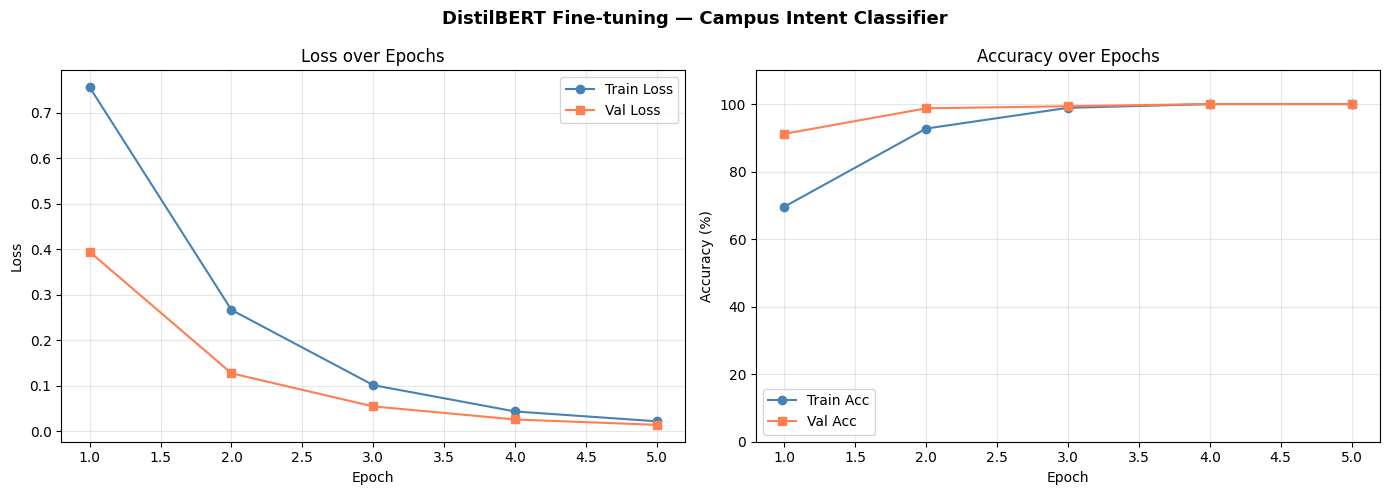

In [67]:
epochs_range = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, history["train_loss"], label="Train Loss", marker='o', color='steelblue')
axes[0].plot(epochs_range, history["val_loss"],   label="Val Loss",   marker='s', color='coral')
axes[0].set_title("Loss over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, [a*100 for a in history["train_acc"]], label="Train Acc", marker='o', color='steelblue')
axes[1].plot(epochs_range, [a*100 for a in history["val_acc"]],   label="Val Acc",   marker='s', color='coral')
axes[1].set_title("Accuracy over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_ylim(0, 110)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("DistilBERT Fine-tuning — Campus Intent Classifier", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("distilbert_training.png", dpi=150, bbox_inches='tight')
plt.show()

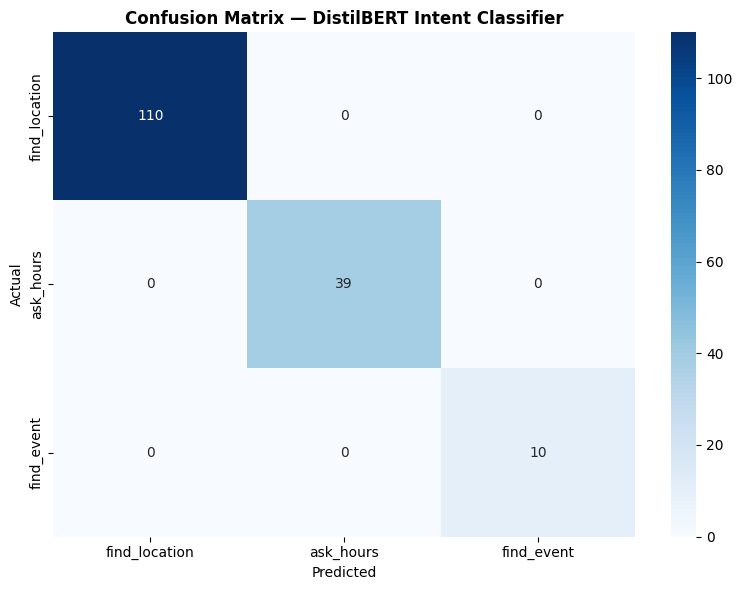

In [68]:
cm = confusion_matrix(val_labels, val_preds)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(INTENT_LABELS.keys()),
            yticklabels=list(INTENT_LABELS.keys()),
            ax=ax)
ax.set_title("Confusion Matrix — DistilBERT Intent Classifier", fontweight='bold')
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig("distilbert_confusion.png", dpi=150, bbox_inches='tight')
plt.show()

In [69]:
from transformers import DistilBertModel

# Load base model for embeddings (no classification head)
embed_model = DistilBertModel.from_pretrained(MODEL_DIR).to(DEVICE)
embed_model.eval()

def get_intent_embedding(text: str) -> np.ndarray:
    """
    Returns 768-dim CLS token embedding for a query.
    This is what feeds into the multimodal fusion MLP.
    """
    encoding = tokenizer(
        text,
        max_length     = MAX_LEN,
        padding        = "max_length",
        truncation     = True,
        return_tensors = "pt",
    )
    input_ids      = encoding["input_ids"].to(DEVICE)
    attention_mask = encoding["attention_mask"].to(DEVICE)

    with torch.no_grad():
        outputs = embed_model(input_ids=input_ids, attention_mask=attention_mask)
        cls_embedding = outputs.last_hidden_state[:, 0, :]  # CLS token

    return cls_embedding.cpu().numpy().squeeze()


def get_intent_label(text: str) -> dict:
    """
    Returns predicted intent label and confidence.
    """
    encoding = tokenizer(
        text,
        max_length     = MAX_LEN,
        padding        = "max_length",
        truncation     = True,
        return_tensors = "pt",
    )
    input_ids      = encoding["input_ids"].to(DEVICE)
    attention_mask = encoding["attention_mask"].to(DEVICE)

    with torch.no_grad():
        outputs    = model(input_ids=input_ids, attention_mask=attention_mask)
        probs      = torch.softmax(outputs.logits, dim=1).cpu().numpy().squeeze()
        pred_label = probs.argmax()

    return {
        "intent":     ID_TO_INTENT[pred_label],
        "confidence": float(probs[pred_label]),
        "all_probs":  {ID_TO_INTENT[i]: float(probs[i]) for i in range(len(probs))},
        "embedding":  get_intent_embedding(text),
    }


# Test
test_queries = [
    "Where is the IT lab?",
    "Is the gym open on Sunday?",
    "What events are at the library?",
    "mechnical eng department where?",
    "canteen kab khulta hai",
]

for q in test_queries:
    result = get_intent_label(q)
    print(f"Query     : {q}")
    print(f"Intent    : {result['intent']} ({result['confidence']:.3f})")
    print(f"All probs : {result['all_probs']}")
    print(f"Embedding : shape={result['embedding'].shape}, mean={result['embedding'].mean():.4f}")
    print("-" * 60)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 2287.00it/s]
[transformers] DistilBertModel LOAD REPORT from: E:\Rohanta_AI_workbook\campus_chatbot\models\distilbert_campus
Key                   | Status     |  | 
----------------------+------------+--+-
pre_classifier.bias   | UNEXPECTED |  | 
classifier.weight     | UNEXPECTED |  | 
pre_classifier.weight | UNEXPECTED |  | 
classifier.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Query     : Where is the IT lab?
Intent    : find_location (0.993)
All probs : {'find_location': 0.9926803708076477, 'ask_hours': 0.0033357341308146715, 'find_event': 0.003983945585787296}
Embedding : shape=(768,), mean=-0.0211
------------------------------------------------------------
Query     : Is the gym open on Sunday?
Intent    : ask_hours (0.986)
All probs : {'find_location': 0.005904242862015963, 'ask_hours': 0.9864261150360107, 'find_event': 0.007669698912650347}
Embedding : shape=(768,), mean=-0.0227
------------------------------------------------------------
Query     : What events are at the library?
Intent    : find_event (0.933)
All probs : {'find_location': 0.030799245461821556, 'ask_hours': 0.03597171977162361, 'find_event': 0.9332290291786194}
Embedding : shape=(768,), mean=-0.0217
------------------------------------------------------------
Query     : mechnical eng department where?
Intent    : find_location (0.989)
All probs : {'find_location': 0.9890947937965393

In [70]:
# comparison of Spacy Rule base and DISTILBErt

In [71]:
import torch
import spacy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import json
import time
from pathlib import Path
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification

# --- Paths ---
FAQ_PATH      = r"E:\Rohanta_AI_workbook\campus_chatbot\data\faq.csv"
KB_PATH       = r"E:\Rohanta_AI_workbook\campus_chatbot\data\campus_kb.json"
SPACY_MODEL   = r"E:\Rohanta_AI_workbook\campus_chatbot\models\campus_spacy\output\model-best"
DISTILBERT_DIR= Path(r"E:\Rohanta_AI_workbook\campus_chatbot\models\distilbert_campus")
DEVICE        = torch.device("cpu")

# --- Load spaCy ---
nlp_spacy = spacy.load(SPACY_MODEL)
print("spaCy model loaded")

# --- Load DistilBERT ---
db_tokenizer = DistilBertTokenizer.from_pretrained(DISTILBERT_DIR)
db_model     = DistilBertForSequenceClassification.from_pretrained(DISTILBERT_DIR).to(DEVICE)
db_model.eval()
print("DistilBERT model loaded")

# --- Load KB ---
with open(KB_PATH, encoding="utf-8") as f:
    kb = json.load(f)
print(f"KB loaded: {len(kb)} entries")

spaCy model loaded


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 676.57it/s]


DistilBERT model loaded
KB loaded: 154 entries


In [72]:
INTENT_PATTERNS = {
    "find_location": [
        r"\bwhere\b", r"\blocation\b", r"\bdirections?\b",
        r"\bhow (do i|to) (get|reach|find|go)\b",
        r"\bfind\b", r"\bnavigate\b", r"\broom\b", r"\bfloor\b", r"\bbuilding\b",
    ],
    "ask_hours": [
        r"\bopen(ing)?\b", r"\bclos(e|ing|ed)\b", r"\bhours?\b",
        r"\btime\b", r"\bwhen\b", r"\bschedule\b", r"\btiming\b", r"\bopen on\b",
    ],
    "find_event": [
        r"\bevents?\b", r"\bworkshops?\b", r"\bseminars?\b",
        r"\bfestival\b", r"\bupcoming\b", r"\bhappening\b",
        r"\bcompetitions?\b", r"\bhackathon\b", r"\bfairs?\b",
        r"\bare there any\b", r"\bscheduled\b", r"\bexhibition\b",
    ],
}

CATEGORY_KEYWORDS = {
    "library":        ["library", "books", "reading"],
    "cafeteria":      ["cafeteria", "canteen", "food", "eat", "meal"],
    "gym":            ["gym", "fitness", "sports", "workout"],
    "it_lab":         ["it lab", "computer lab", "pc"],
    "department":     ["department", "dept"],
    "hod_office":     ["hod", "head of department"],
    "auditorium":     ["auditorium"],
    "medical_center": ["medical", "health", "clinic", "doctor"],
    "career_center":  ["career centre", "career services", "career advice"],
    "student_union":  ["student union", "socialise"],
    "admin_office":   ["admissions", "registry", "enrollment"],
    "lab":            ["lab", "laboratory"],
    "classroom":      ["classroom"],
    "seminar_room":   ["seminar room", "seminar"],
    "printing_room":  ["print", "photocopy"],
    "security_office":["security", "guard"],
}

ENTITY_MAP = {
    "library":       ["library", "books", "study desks", "place to study"],
    "cafeteria":     ["cafeteria", "canteen", "food", "dining area", "eat"],
    "coffee shop":   ["coffee", "cafe", "hot drink"],
    "student union": ["student union", "socialise"],
    "gym":           ["gym", "fitness", "sports centre", "exercise", "workout"],
    "it lab":        ["it lab", "computer lab", "computer room", "use a computer"],
    "admissions":    ["admissions", "registry", "enrollment", "dissertation"],
    "career":        ["career centre", "career services", "career advice", "cv help"],
    "medical":       ["medical", "doctor", "health centre", "clinic"],
    "auditorium":    ["auditorium", "main hall"],
    "security":      ["security", "campus security"],
    "research lab":  ["research lab", "innovation centre", "hackathon"],
    "engineering":   ["engineering block", "engineering college", "engineering building"],
}

OFFICIAL_ENTITY_NAME = {
    "library":       "Main Library",
    "cafeteria":     "Main Cafeteria",
    "coffee shop":   "Campus Coffee Shop",
    "student union": "Student Union",
    "gym":           "Sports & Fitness Centre",
    "it lab":        "IT & Computer Lab",
    "admissions":    "Admissions & Registry Office",
    "career":        "Career Services Centre",
    "medical":       "Medical & Counselling Centre",
    "auditorium":    "Main Auditorium",
    "security":      "Campus Security Office",
    "research lab":  "Research & Innovation Lab",
    "engineering":   "Engineering College - Main Block",
}

KB_ENTITY_MAP = {}
for entry in kb:
    KB_ENTITY_MAP[entry["name"].lower()] = entry["name"]

DEPT_TO_NAME = {
    "mechanical engineering": "Mechanical Engineering Department",
    "chemical engineering":   "Chemical Engineering Department",
    "information technology": "Information Technology Department",
    "computer engineering":   "Computer Engineering Department",
    "entc":                   "Electronics & Telecommunication (ENTC) Department",
    "electrical engineering": "Electrical Engineering Department",
    "civil engineering":      "Civil Engineering Department",
}

DEPT_TO_HOD = {
    "mechanical": "HOD Office ME-HOD101",
    "chemical":   "HOD Office CE-HOD202",
    "information technology": "HOD Office IT-HOD303",
    "computer":   "HOD Office CSE-HOD404",
    "entc":       "HOD Office ENTC-HOD505",
    "electrical": "HOD Office EE-HOD606",
    "civil":      "HOD Office CVL-HOD707",
}

DEPT_TO_TR = {
    "mechanical": "Teachers Room ME-TR101",
    "chemical":   "Teachers Room CE-TR202",
    "information technology": "Teachers Room IT-TR303",
    "computer":   "Teachers Room CSE-TR404",
    "entc":       "Teachers Room ENTC-TR505",
    "electrical": "Teachers Room EE-TR606",
    "civil":      "Teachers Room CVL-TR707",
}

RULES_INTENT_MAP = {
    "find_location": "find_location",
    "opening_hours": "ask_hours",
    "events":        "find_event",
    "description":   "find_location",
    "navigation":    "find_location",
    "general":       "find_location",
}


def rules_classify_intent(query):
    q = query.lower()
    scores = {intent: 0 for intent in INTENT_PATTERNS}
    for intent, patterns in INTENT_PATTERNS.items():
        for pat in patterns:
            if re.search(pat, q):
                scores[intent] += 1
    best = max(scores, key=lambda k: scores[k])
    return RULES_INTENT_MAP.get(best if scores[best] > 0 else "general", "find_location")


def rules_extract_entities(query):
    q = query.lower()
    found = []

    if any(kw in q for kw in ["teachers room", "faculty room", "staff room", "professor in"]):
        for dept_key, tr_name in DEPT_TO_TR.items():
            if dept_key in q:
                return [tr_name]

    if any(kw in q for kw in ["hod", "head of", "hod office", "hod room"]):
        for dept_key, hod_name in DEPT_TO_HOD.items():
            if dept_key in q:
                return [hod_name]

    for name_lower, official_name in KB_ENTITY_MAP.items():
        if name_lower in q:
            if official_name not in found:
                found.append(official_name)
    if found:
        return found

    for dept_kw, dept_name in DEPT_TO_NAME.items():
        if dept_kw in q:
            if dept_name not in found:
                found.append(dept_name)
    if found:
        return found

    for key, keywords in ENTITY_MAP.items():
        if any(kw in q for kw in keywords):
            official = OFFICIAL_ENTITY_NAME.get(key, key)
            if official not in found:
                found.append(official)

    return found


print("Rule-based system ready")

Rule-based system ready


In [73]:
SPACY_INTENT_MAP = {
    "find_location": "find_location",
    "ask_hours":     "ask_hours",
    "find_event":    "find_event",
}

ID_TO_INTENT = {0: "find_location", 1: "ask_hours", 2: "find_event"}
MAX_LEN      = 64


def spacy_predict(query):
    doc    = nlp_spacy(query)
    intent = max(doc.cats, key=lambda k: doc.cats[k])
    intent = SPACY_INTENT_MAP.get(intent, intent)
    ents   = [re.sub(r'[?!.,]+$', '', e.text).strip() for e in doc.ents]
    return intent, ents


def distilbert_predict(query):
    encoding = db_tokenizer(
        query,
        max_length=MAX_LEN,
        padding="max_length",
        truncation=True,
        return_tensors="pt",
    )
    with torch.no_grad():
        outputs = db_model(
            input_ids      = encoding["input_ids"].to(DEVICE),
            attention_mask = encoding["attention_mask"].to(DEVICE),
        )
        pred = outputs.logits.argmax(dim=1).item()
    intent = ID_TO_INTENT[pred]
    # DistilBERT is classification only — no entity extraction
    return intent, []


print("Predict functions ready")

Predict functions ready


In [74]:
df_faq = pd.read_csv(FAQ_PATH)

INTENT_MAP = {
    "find_location": "find_location",
    "ask_hours":     "ask_hours",
    "find_event":    "find_event",
}

results = []
for _, row in df_faq.iterrows():
    query           = row["query"]
    expected_intent = INTENT_MAP.get(row["intent"], row["intent"])
    expected_entity = row["entity"]

    # Rules
    t0 = time.time()
    r_intent  = rules_classify_intent(query)
    r_ents    = rules_extract_entities(query)
    r_time    = (time.time() - t0) * 1000

    # spaCy
    t0 = time.time()
    s_intent, s_ents = spacy_predict(query)
    s_time    = (time.time() - t0) * 1000

    # DistilBERT
    t0 = time.time()
    d_intent, d_ents = distilbert_predict(query)
    d_time    = (time.time() - t0) * 1000

    # Entity correct check
    def ent_correct(pred_ents, expected):
        return any(
            expected.lower() in e.lower() or e.lower() in expected.lower()
            for e in pred_ents
        ) if pred_ents else False

    results.append({
        "query":            query,
        "expected_intent":  expected_intent,
        "expected_entity":  expected_entity,

        "rules_intent":     r_intent,
        "rules_ent_correct":ent_correct(r_ents, expected_entity),
        "rules_time_ms":    r_time,

        "spacy_intent":     s_intent,
        "spacy_ents":       s_ents,
        "spacy_ent_correct":ent_correct(s_ents, expected_entity),
        "spacy_time_ms":    s_time,

        "db_intent":        d_intent,
        "db_time_ms":       d_time,

        "rules_intent_correct": r_intent == expected_intent,
        "spacy_intent_correct": s_intent == expected_intent,
        "db_intent_correct":    d_intent == expected_intent,
    })

df_results = pd.DataFrame(results)
print(f"Done. Total samples: {len(df_results)}")

Done. Total samples: 734


In [75]:
total = len(df_results)

summary = {
    "Model":           ["Rules", "spaCy", "DistilBERT"],
    "Intent Accuracy": [
        df_results["rules_intent_correct"].sum() / total * 100,
        df_results["spacy_intent_correct"].sum() / total * 100,
        df_results["db_intent_correct"].sum()    / total * 100,
    ],
    "Entity Accuracy": [
        df_results["rules_ent_correct"].sum() / total * 100,
        df_results["spacy_ent_correct"].sum() / total * 100,
        "N/A",
    ],
    "Avg Time (ms)": [
        df_results["rules_time_ms"].mean(),
        df_results["spacy_time_ms"].mean(),
        df_results["db_time_ms"].mean(),
    ],
}

df_summary = pd.DataFrame(summary)
print("\n=== Overall Comparison ===")
print(df_summary.to_string(index=False))


=== Overall Comparison ===
     Model  Intent Accuracy Entity Accuracy  Avg Time (ms)
     Rules        70.435967       82.152589       0.231999
     spaCy        99.863760       64.713896      12.559088
DistilBERT       100.000000             N/A     140.891574


In [76]:
intent_rows = []
for intent in ["find_location", "ask_hours", "find_event"]:
    mask  = df_results["expected_intent"] == intent
    total = mask.sum()
    intent_rows.append({
        "intent":        intent,
        "total":         total,
        "rules_acc":     df_results[mask]["rules_intent_correct"].sum() / total * 100,
        "spacy_acc":     df_results[mask]["spacy_intent_correct"].sum() / total * 100,
        "db_acc":        df_results[mask]["db_intent_correct"].sum()    / total * 100,
        "rules_ent_acc": df_results[mask]["rules_ent_correct"].sum()    / total * 100,
        "spacy_ent_acc": df_results[mask]["spacy_ent_correct"].sum()    / total * 100,
    })

df_intent = pd.DataFrame(intent_rows)
print("\n=== Per Intent Accuracy ===")
print(df_intent.to_string(index=False))


=== Per Intent Accuracy ===
       intent  total  rules_acc  spacy_acc  db_acc  rules_ent_acc  spacy_ent_acc
find_location    517      100.0  99.806576   100.0      76.595745      55.899420
    ask_hours    184        0.0 100.000000   100.0      98.913043      90.217391
   find_event     33        0.0 100.000000   100.0      75.757576      60.606061


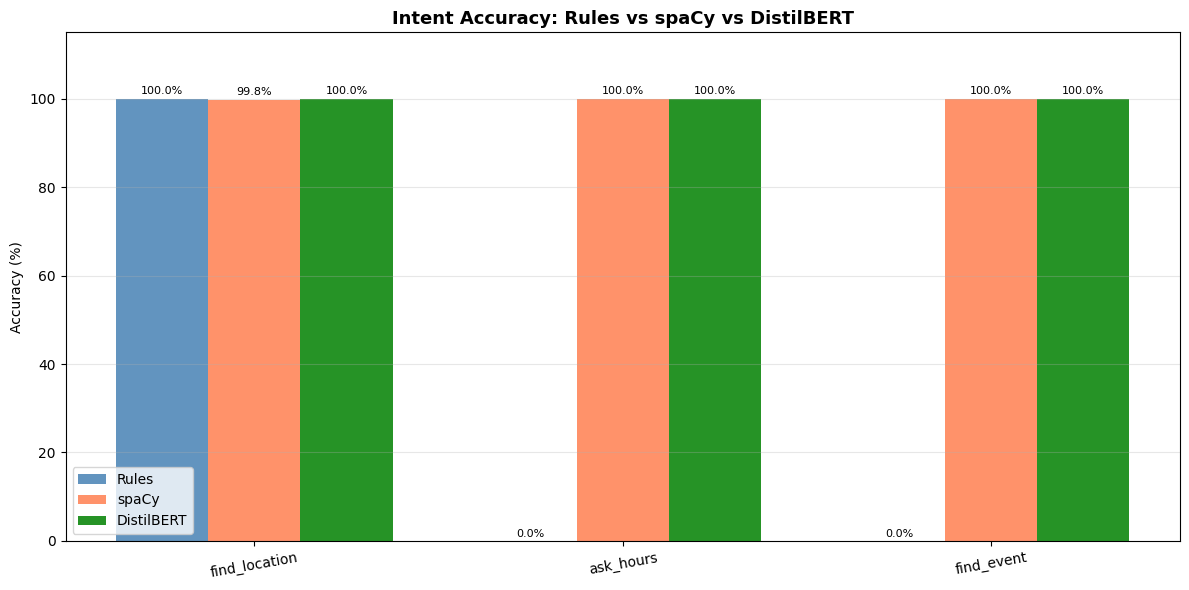

In [77]:
x     = np.arange(len(df_intent))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
b1 = ax.bar(x - width, df_intent["rules_acc"], width, label="Rules",      color="steelblue", alpha=0.85)
b2 = ax.bar(x,          df_intent["spacy_acc"], width, label="spaCy",      color="coral",     alpha=0.85)
b3 = ax.bar(x + width,  df_intent["db_acc"],    width, label="DistilBERT", color="green",     alpha=0.85)

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.5,
                f'{h:.1f}%', ha='center', va='bottom', fontsize=8)

ax.set_title("Intent Accuracy: Rules vs spaCy vs DistilBERT", fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(df_intent["intent"], rotation=10)
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(0, 115)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("intent_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

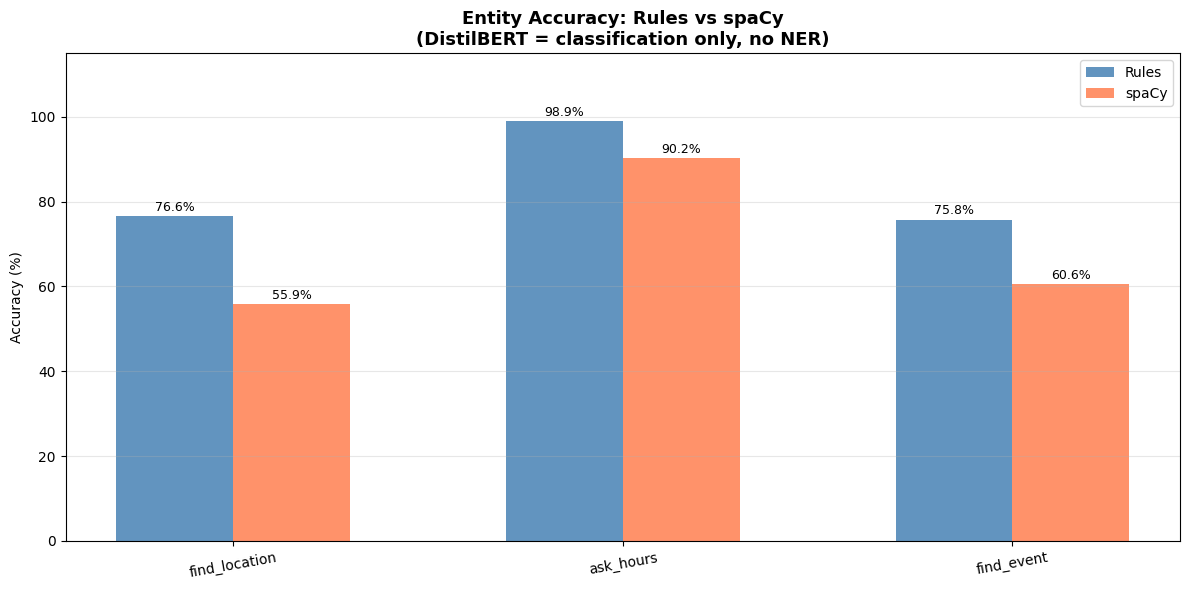

In [78]:
x     = np.arange(len(df_intent))
width = 0.3

fig, ax = plt.subplots(figsize=(12, 6))
b1 = ax.bar(x - width/2, df_intent["rules_ent_acc"], width, label="Rules",  color="steelblue", alpha=0.85)
b2 = ax.bar(x + width/2, df_intent["spacy_ent_acc"], width, label="spaCy",  color="coral",     alpha=0.85)

for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.5,
                f'{h:.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_title("Entity Accuracy: Rules vs spaCy\n(DistilBERT = classification only, no NER)",
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(df_intent["intent"], rotation=10)
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(0, 115)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("entity_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

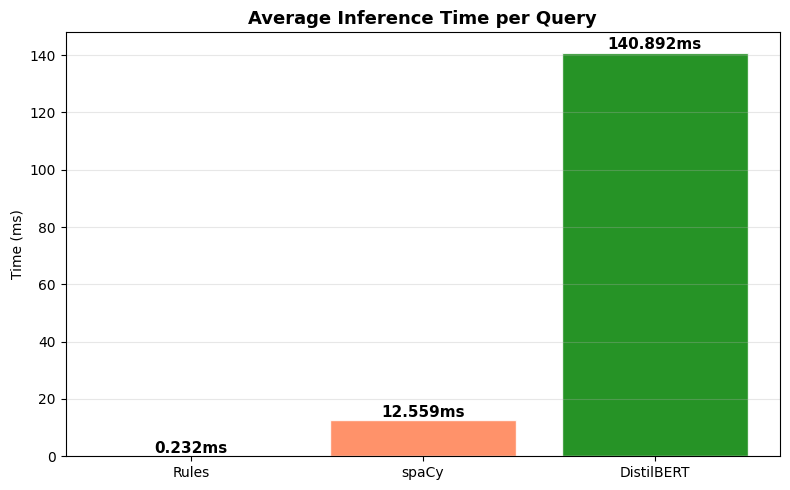

In [79]:
models    = ["Rules", "spaCy", "DistilBERT"]
avg_times = [
    df_results["rules_time_ms"].mean(),
    df_results["spacy_time_ms"].mean(),
    df_results["db_time_ms"].mean(),
]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(models, avg_times,
              color=["steelblue", "coral", "green"], alpha=0.85, edgecolor='white')

for bar, val in zip(bars, avg_times):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}ms', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title("Average Inference Time per Query", fontsize=13, fontweight='bold')
ax.set_ylabel("Time (ms)")
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("speed_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

In [80]:
# Calculate real numbers from df_results
total = len(df_results)

rules_intent_acc  = df_results["rules_intent_correct"].sum() / total * 100
spacy_intent_acc  = df_results["spacy_intent_correct"].sum() / total * 100
db_intent_acc     = df_results["db_intent_correct"].sum()    / total * 100

rules_entity_acc  = df_results["rules_ent_correct"].sum() / total * 100
spacy_entity_acc  = df_results["spacy_ent_correct"].sum() / total * 100

rules_avg_time    = df_results["rules_time_ms"].mean()
spacy_avg_time    = df_results["spacy_time_ms"].mean()
db_avg_time       = df_results["db_time_ms"].mean()

final_summary = pd.DataFrame({
    "Metric": [
        "Intent Accuracy (%)",
        "Entity Accuracy (%)",
        "Avg Time (ms)",
        "Works Offline",
        "Handles Typos",
        "Produces Embedding",
    ],
    "Rules": [
        f"{rules_intent_acc:.1f}%",
        f"{rules_entity_acc:.1f}%",
        f"{rules_avg_time:.3f}ms",
        "Yes",
        "No",
        "No",
    ],
    "spaCy": [
        f"{spacy_intent_acc:.1f}%",
        f"{spacy_entity_acc:.1f}%",
        f"{spacy_avg_time:.3f}ms",
        "Yes",
        "Partial",
        "No",
    ],
    "DistilBERT": [
        f"{db_intent_acc:.1f}%",
        "N/A (classification only)",
        f"{db_avg_time:.3f}ms",
        "Yes",
        "Yes",
        "Yes (768-dim)",
    ],
})

print("\n=== Final Model Comparison Summary ===")
print(final_summary.to_string(index=False))


=== Final Model Comparison Summary ===
             Metric   Rules    spaCy                DistilBERT
Intent Accuracy (%)   70.4%    99.9%                    100.0%
Entity Accuracy (%)   82.2%    64.7% N/A (classification only)
      Avg Time (ms) 0.232ms 12.559ms                 140.892ms
      Works Offline     Yes      Yes                       Yes
      Handles Typos      No  Partial                       Yes
 Produces Embedding      No       No             Yes (768-dim)
